# Travel guru 
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Exploratory data analysis
* Data Cleaning
* Data Pre-Processing
* Model Training 
* Choose best model

In [ ]:
# import os
# print(os.getcwd())
# #  ouput:d:\labmentix\major\TravelGuru\travelguru-v5\backend\app\mlops\notebook
# import sys
# for p in sys.path:
#     print(p)
# # output
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\python312.zip
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\DLLs
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\Lib
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312

# # C:\Users\uditn\AppData\Roaming\Python\Python312\site-packages
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\Lib\site-packages
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\Lib\site-packages\win32
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\Lib\site-packages\win32\lib
# # c:\Users\uditn\AppData\Local\Programs\Python\Python312\Lib\site-packages\Pythonwin

d:\labmentix\major\TravelGuru\travelguru-v5\backend\app\mlops\notebook


In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")  # points to mlops/
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added to sys.path:", PROJECT_ROOT)


Project root added to sys.path: d:\labmentix\major\TravelGuru\travelguru-v5\backend\app\mlops


### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. 
The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

## 1) Problem statement.

* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. 
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist travel applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to check if travel get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the travel should be certified or denied based on the certain criteria which influences the decision.

## 2) Data Collection.
* The Dataset is part of Office of Foreign Labor Certification (OFLC)
* The data consists of 25480 Rows and 12 Columns

https://www.kaggle.com/datasets/moro23/easyvisa-dataset

### 2.1 Import Data and Required Packages

**Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

**Import the CSV Data as Pandas DataFrame**

In [4]:
from loggings import setup_logging
from exception import dump_exception
from utils.db_utils import read_sql_to_df
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

setup_logging()

flights_df = read_sql_to_df("""
SELECT origin, destination, airline, dep_time, arr_time,
       duration_minutes, price, travel_date, cabin_class
FROM database_ml.flights;
""")

hotels_df = read_sql_to_df("""
SELECT hotel_name, city, rating, price_per_night,
       amenities, star_category
FROM database_ml.hotels;
""")

cabs_df = read_sql_to_df("""
SELECT ride_date, ride_time, pickup_location, drop_location,
       vehicle_type, distance_km, price,
       driver_rating, customer_rating
FROM database_ml.cabs;
""")

2026-01-16 23:20:59,469 utils.db_utils INFO Running query: 
SELECT origin, destination, airline, dep_time, arr_time,
       duration_minute
2026-01-16 23:21:04,830 utils.db_utils INFO Loaded 2906 rows
2026-01-16 23:21:04,836 utils.db_utils INFO Running query: 
SELECT hotel_name, city, rating, price_per_night,
       amenities, star_catego
2026-01-16 23:21:07,084 utils.db_utils INFO Loaded 1101 rows
2026-01-16 23:21:07,088 utils.db_utils INFO Running query: 
SELECT ride_date, ride_time, pickup_location, drop_location,
       vehicle_typ
2026-01-16 23:21:17,325 utils.db_utils INFO Loaded 33484 rows


**Show Top 5 Records**

In [5]:
print("Flights Dataset Preview")
display(flights_df.head())

print("Hotels Dataset Preview")
display(hotels_df.head())

print("Cabs Dataset Preview")
display(cabs_df.head())


Flights Dataset Preview


,origin,destination,airline,dep_time,arr_time,duration_minutes,price,travel_date,cabin_class
0,BOM,DEL,IndiGo,1900-01-01 08:30:00,1900-01-01 10:25:00,115,6153.0,2022-02-14,Economy
1,BOM,DEL,IndiGo,1900-01-01 07:45:00,1900-01-01 09:50:00,125,5943.0,2022-02-14,Economy
2,BOM,DEL,Vistara,1900-01-01 12:25:00,1900-01-01 14:30:00,125,6249.0,2022-02-14,Economy
3,BOM,DEL,IndiGo,1900-01-01 10:05:00,1900-01-01 12:15:00,130,5943.0,2022-02-14,Economy
4,BOM,DEL,IndiGo,1900-01-01 13:40:00,1900-01-01 15:50:00,130,5943.0,2022-02-14,Economy


Hotels Dataset Preview


,hotel_name,city,rating,price_per_night,amenities,star_category
0,Crowne Plaza Kochi,kochi,4.6,8854.0,None,5
1,Trident Hotel Cochin,kochi,4.5,6441.0,None,4
2,The Galaxy Suites,kochi,3.8,831.0,None,4
3,The Renai cochin,kochi,4.2,2768.0,None,4
4,Ramada by Wyndham Kochi,kochi,4.5,8938.0,None,4


Cabs Dataset Preview


,ride_date,ride_time,pickup_location,drop_location,vehicle_type,distance_km,price,driver_rating,customer_rating
0,2024-01-28,06:00:00,Area-3,Area-2,Auto,28.50,868.06,4.4,4.4
1,2024-01-17,21:00:00,Area-38,Area-26,Prime Sedan,25.18,348.04,4.5,4.7
2,2024-01-30,00:00:00,Area-47,Area-8,eBike,17.67,56.33,3.6,3.3
3,2024-01-22,08:00:00,Area-11,Area-35,Prime SUV,24.94,1971.38,3.2,3.7
4,2024-01-12,07:00:00,Area-43,Area-42,Prime Sedan,13.15,1130.15,3.1,3.0


**Shape of the dataset**

In [6]:
print("Flights shape:", flights_df.shape)
print("Hotels shape:", hotels_df.shape)
print("Cabs shape:", cabs_df.shape)


Flights shape: (2906, 9)
Hotels shape: (1101, 6)
Cabs shape: (33484, 9)


**Summary of the dataset**

In [7]:
print("Flights Summary Statistics")
display(flights_df.describe())

print("Hotels Summary Statistics")
display(hotels_df.describe())

print("Cabs Summary Statistics")
display(cabs_df.describe())


Flights Summary Statistics


,dep_time,arr_time,duration_minutes,price
count,2906,2906,2906.000000,2906.000000
mean,1900-01-01 13:56:30.949758976,1900-01-01 14:54:49.676531456,123.721610,4101.216793
min,1900-01-01 02:00:00,1900-01-01 00:05:00,80.000000,1828.000000
25%,1900-01-01 08:30:00,1900-01-01 09:51:15,110.000000,2301.000000
50%,1900-01-01 14:20:00,1900-01-01 15:00:00,125.000000,3199.500000
75%,1900-01-01 19:00:00,1900-01-01 20:35:00,135.000000,5943.000000
max,1900-01-01 23:45:00,1900-01-01 23:55:00,190.000000,14282.000000
std,NaN,NaN,22.049278,2043.825263


Hotels Summary Statistics


,rating,price_per_night,star_category
count,1101.000000,1101.000000,1101.000000
mean,4.162398,4209.425068,4.077203
std,0.361340,4622.076878,0.386638
min,2.600000,448.000000,3.000000
25%,4.000000,1836.000000,4.000000
50%,4.200000,2940.000000,4.000000
75%,4.400000,4936.000000,4.000000
max,5.000000,64900.000000,5.000000


Cabs Summary Statistics


,distance_km,price,driver_rating,customer_rating
count,33484.000000,33484.000000,33484.00000,33484.000000
mean,25.447143,1023.374286,4.00304,4.001726
std,14.175953,563.595072,0.57968,0.579177
min,1.000000,50.100000,3.00000,3.000000
25%,13.100000,532.942500,3.50000,3.500000
50%,25.460000,1023.350000,4.00000,4.000000
75%,37.670000,1514.677500,4.50000,4.500000
max,50.000000,2000.000000,5.00000,5.000000


**Check Datatypes in the dataset**

In [9]:
print("Flights Info")
flights_df.info()

print("\nHotels Info")
hotels_df.info()

print("\nCabs Info")
cabs_df.info()


Flights Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906 entries, 0 to 2905
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   origin            2906 non-null   object        
 1   destination       2906 non-null   object        
 2   airline           2906 non-null   object        
 3   dep_time          2906 non-null   datetime64[ns]
 4   arr_time          2906 non-null   datetime64[ns]
 5   duration_minutes  2906 non-null   int64         
 6   price             2906 non-null   float64       
 7   travel_date       2906 non-null   object        
 8   cabin_class       2906 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 204.5+ KB

Hotels Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1101 entries, 0 to 1100
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -

## 3. EXPLORING DATA

In [10]:
# =========================================
# 3. EXPLORING DATA – FLIGHTS
# =========================================

flight_numeric_features = [
    col for col in flights_df.columns
    if flights_df[col].dtype != 'O'
]

flight_categorical_features = [
    col for col in flights_df.columns
    if flights_df[col].dtype == 'O'
]

print(f"We have {len(flight_numeric_features)} numerical features:", flight_numeric_features)
print(f"\nWe have {len(flight_categorical_features)} categorical features:", flight_categorical_features)


We have 4 numerical features: ['dep_time', 'arr_time', 'duration_minutes', 'price']

We have 5 categorical features: ['origin', 'destination', 'airline', 'travel_date', 'cabin_class']


In [11]:
# =========================================
# EXPLORING DATA – HOTELS
# =========================================

hotel_numeric_features = [
    col for col in hotels_df.columns
    if hotels_df[col].dtype != 'O'
]

hotel_categorical_features = [
    col for col in hotels_df.columns
    if hotels_df[col].dtype == 'O'
]

print(f"We have {len(hotel_numeric_features)} numerical features:", hotel_numeric_features)
print(f"\nWe have {len(hotel_categorical_features)} categorical features:", hotel_categorical_features)


We have 3 numerical features: ['rating', 'price_per_night', 'star_category']

We have 3 categorical features: ['hotel_name', 'city', 'amenities']


In [12]:
# =========================================
# EXPLORING DATA – CABS
# =========================================

cab_numeric_features = [
    col for col in cabs_df.columns
    if cabs_df[col].dtype != 'O'
]

cab_categorical_features = [
    col for col in cabs_df.columns
    if cabs_df[col].dtype == 'O'
]

print(f"We have {len(cab_numeric_features)} numerical features:", cab_numeric_features)
print(f"\nWe have {len(cab_categorical_features)} categorical features:", cab_categorical_features)


We have 4 numerical features: ['distance_km', 'price', 'driver_rating', 'customer_rating']

We have 5 categorical features: ['ride_date', 'ride_time', 'pickup_location', 'drop_location', 'vehicle_type']


## 3.2 Proportion of Categorical Values (Distribution Bias)

In [13]:
# FLIGHT
for col in flight_categorical_features:
    print(f"\n{col} value distribution (%)")
    print(flights_df[col].value_counts(normalize=True) * 100)
    print("-" * 40)



origin value distribution (%)
origin
BOM    48.898830
DEL    20.853407
BLR    11.286992
MAA     7.398486
CCU     6.400551
HYD     5.161734
Name: proportion, dtype: float64
----------------------------------------

destination value distribution (%)
destination
BOM    51.101170
DEL    19.236063
BLR    10.839642
MAA     7.536132
CCU     6.228493
HYD     5.058500
Name: proportion, dtype: float64
----------------------------------------

airline value distribution (%)
airline
IndiGo            33.551273
Vistara           27.494838
Go First          18.410186
Air India         11.803166
SpiceJet           5.161734
AirAsia India      3.578802
Name: proportion, dtype: float64
----------------------------------------

travel_date value distribution (%)
travel_date
2022-02-22    7.295251
2022-02-25    7.123193
2022-02-20    7.019959
2022-02-23    6.985547
2022-02-17    6.985547
2022-02-21    6.985547
2022-02-19    6.916724
2022-02-16    6.882312
2022-02-24    6.813489
2022-02-26    6.607020
20

In [14]:
# HOTEL
for col in hotel_categorical_features:
    print(f"\n{col} value distribution (%)")
    print(hotels_df[col].value_counts(normalize=True) * 100)
    print("-" * 40)



hotel_name value distribution (%)
hotel_name
The Orchard Retreat & Spa, Srinagar                                                               0.272480
The Montreal, Srinagar- Best Hotels/4 Star Hotels/Hotel Near Dal Lake/Hotel Near Mughal Garden    0.272480
Zostel Srinagar                                                                                   0.272480
The Wilderness Retreat                                                                            0.181653
IIDL Suites                                                                                       0.181653
                                                                                                    ...   
Paradise Inn Beach Resort                                                                         0.090827
Rachanas Black Beach Resort                                                                       0.090827
Hindustan Beach Retreat                                                                           

In [15]:
# CAB
for col in cab_categorical_features:
    print(f"\n{col} value distribution (%)")
    print(cabs_df[col].value_counts(normalize=True) * 100)
    print("-" * 40)



ride_date value distribution (%)
ride_date
2024-01-12    3.518098
2024-01-11    3.485247
2024-01-30    3.428503
2024-01-14    3.428503
2024-01-18    3.425517
2024-01-13    3.398638
2024-01-10    3.383706
2024-01-22    3.383706
2024-01-02    3.344881
2024-01-29    3.344881
2024-01-28    3.338908
2024-01-15    3.338908
2024-01-26    3.332935
2024-01-05    3.332935
2024-01-27    3.326962
2024-01-23    3.315016
2024-01-06    3.315016
2024-01-17    3.306057
2024-01-04    3.297097
2024-01-25    3.294111
2024-01-20    3.288138
2024-01-01    3.285151
2024-01-09    3.285151
2024-01-19    3.279178
2024-01-21    3.273205
2024-01-07    3.264246
2024-01-03    3.252300
2024-01-24    3.225421
2024-01-16    3.195556
2024-01-08    3.174651
2024-01-31    0.137379
Name: proportion, dtype: float64
----------------------------------------

ride_time value distribution (%)
ride_time
15:00:00    4.369251
00:00:00    4.297575
03:00:00    4.294588
17:00:00    4.279656
02:00:00    4.270696
12:00:00    4.270696

**Insights**
 - `case_id` have unique vlaues for each column which can be dropped as it it of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.

## Univariate Analysis

* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

Other Type of Analysis are
* **Bivariate Analysis:** The analysis of two variables.
* **Multivariate Analysis:** The analysis of two or more variables.

### Numerical Features

FLIGHT


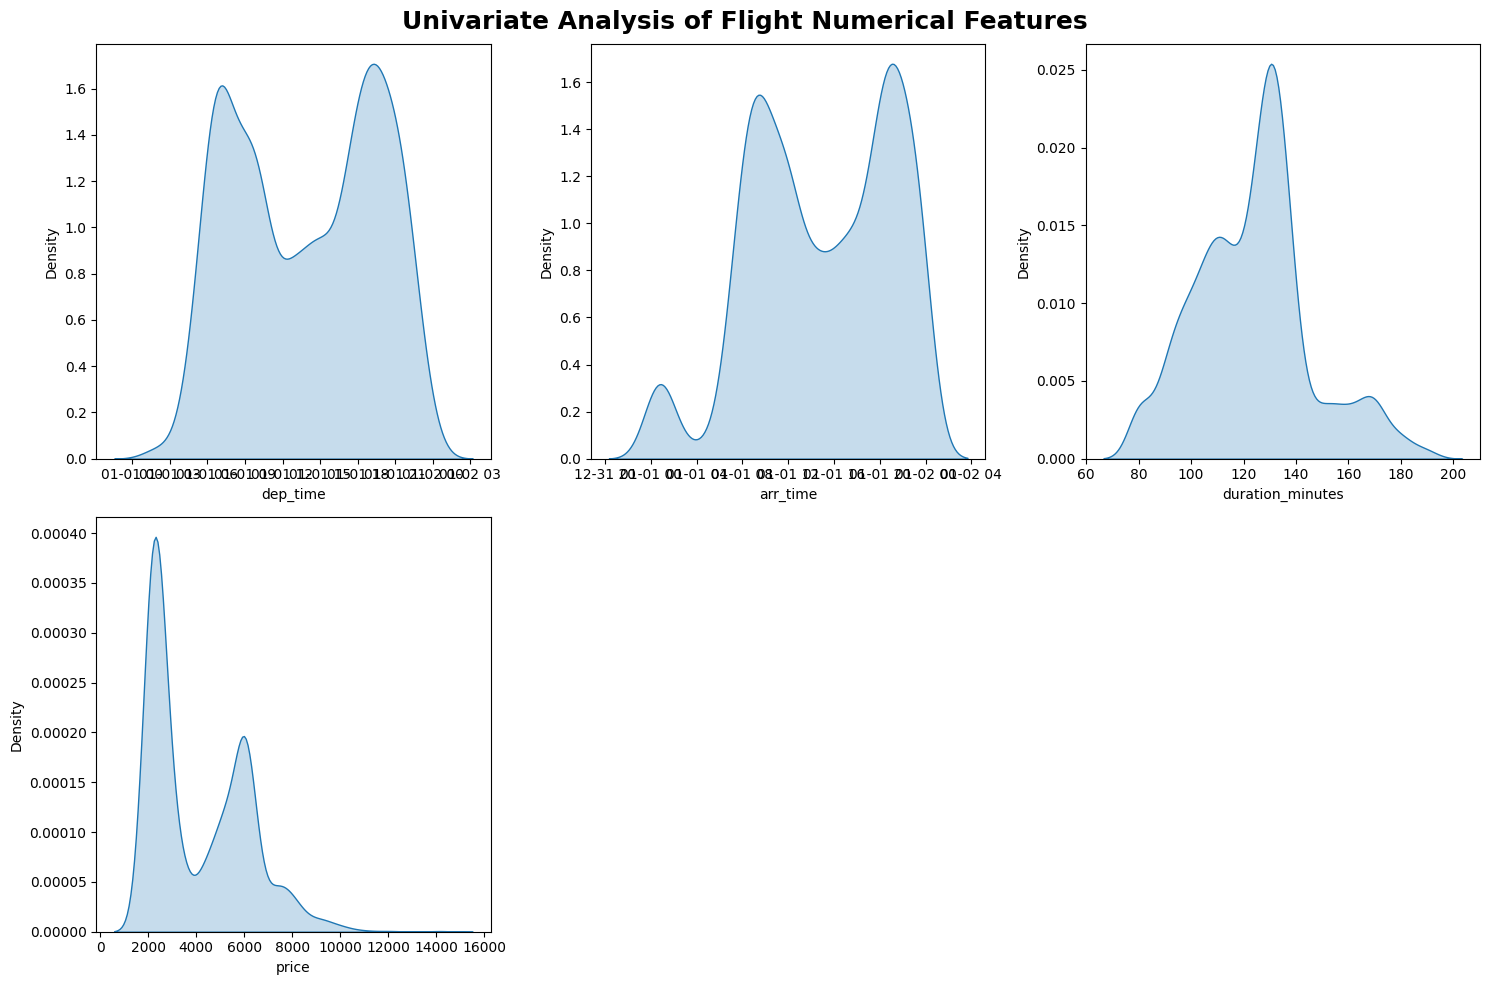

In [16]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Flight Numerical Features',
             fontsize=18, fontweight='bold')

for i, col in enumerate(flight_numeric_features):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(x=flights_df[col], fill=True)
    plt.xlabel(col)
    plt.tight_layout()


HOTEL

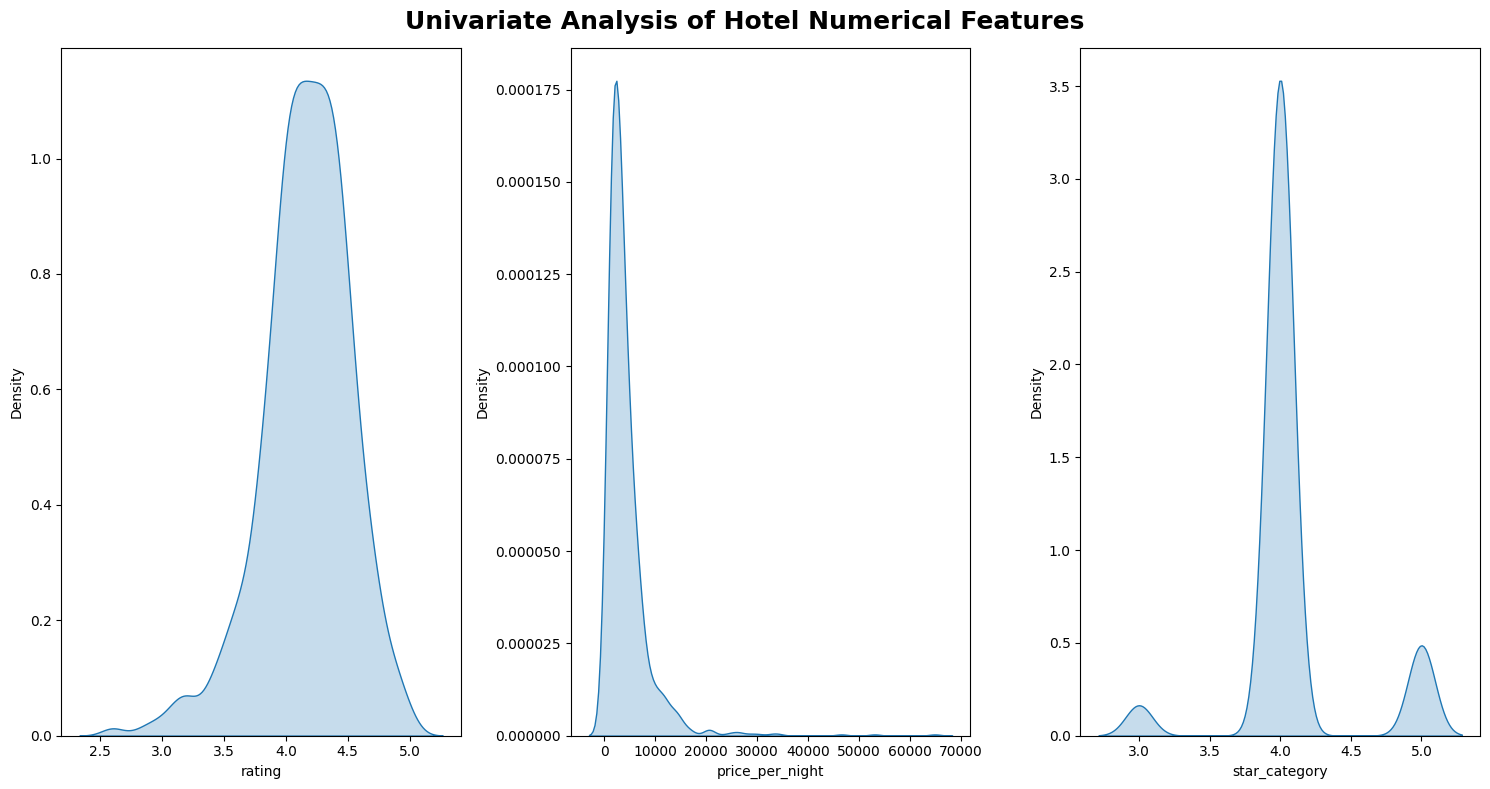

In [17]:
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Hotel Numerical Features',
             fontsize=18, fontweight='bold')

for i, col in enumerate(hotel_numeric_features):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(x=hotels_df[col], fill=True)
    plt.xlabel(col)
    plt.tight_layout()


CAB

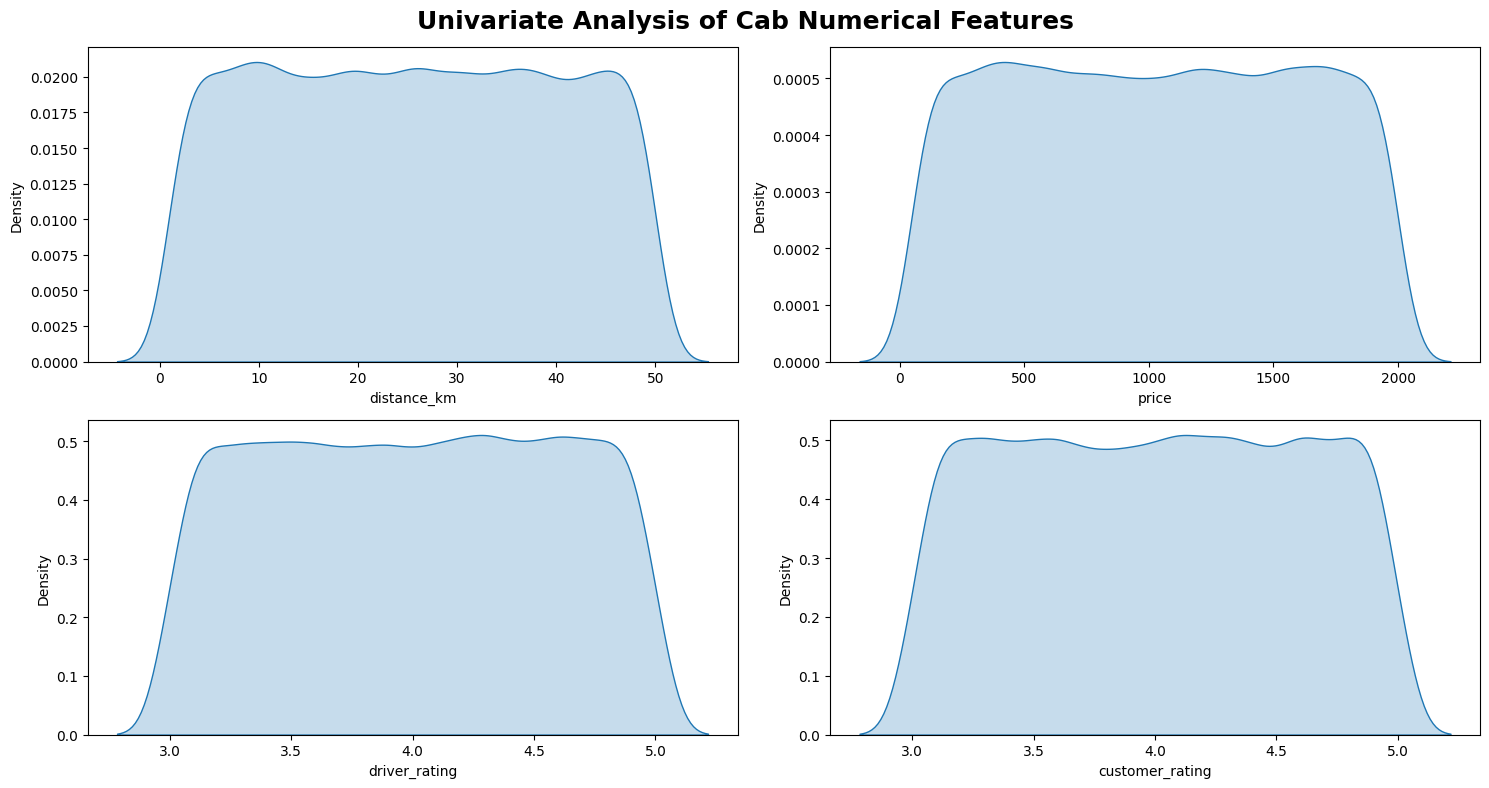

In [18]:
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Cab Numerical Features',
             fontsize=18, fontweight='bold')

for i, col in enumerate(cab_numeric_features):
    plt.subplot(2, 2, i + 1)
    sns.kdeplot(x=cabs_df[col], fill=True)
    plt.xlabel(col)
    plt.tight_layout()


**Insights**
 - `no_of_employees` column looks more skewed but it may be because of outlies.
 - `yr_of_estab` is a discrete feature.
 - `privailing-price` is a right-skewed distribution.

### 3.4 Univariate Analysis – Categorical Features

FLIGHT

2026-01-16 23:21:56,811 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-16 23:21:56,819 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


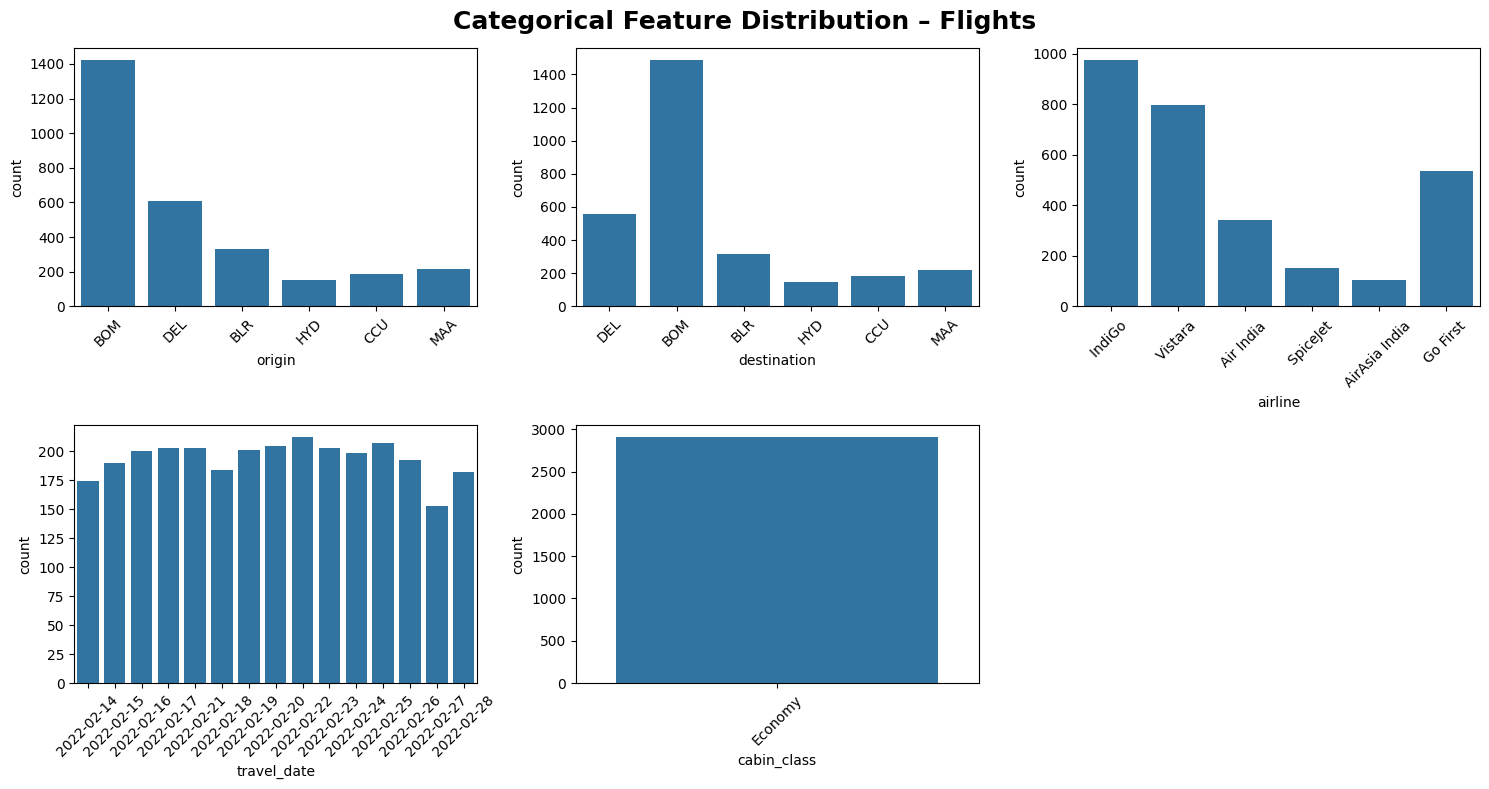

In [19]:
plt.figure(figsize=(15, 8))
plt.suptitle('Categorical Feature Distribution – Flights',
             fontsize=18, fontweight='bold')

for i, col in enumerate(flight_categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=flights_df[col])
    plt.xticks(rotation=45)
    plt.tight_layout()


HOTEL

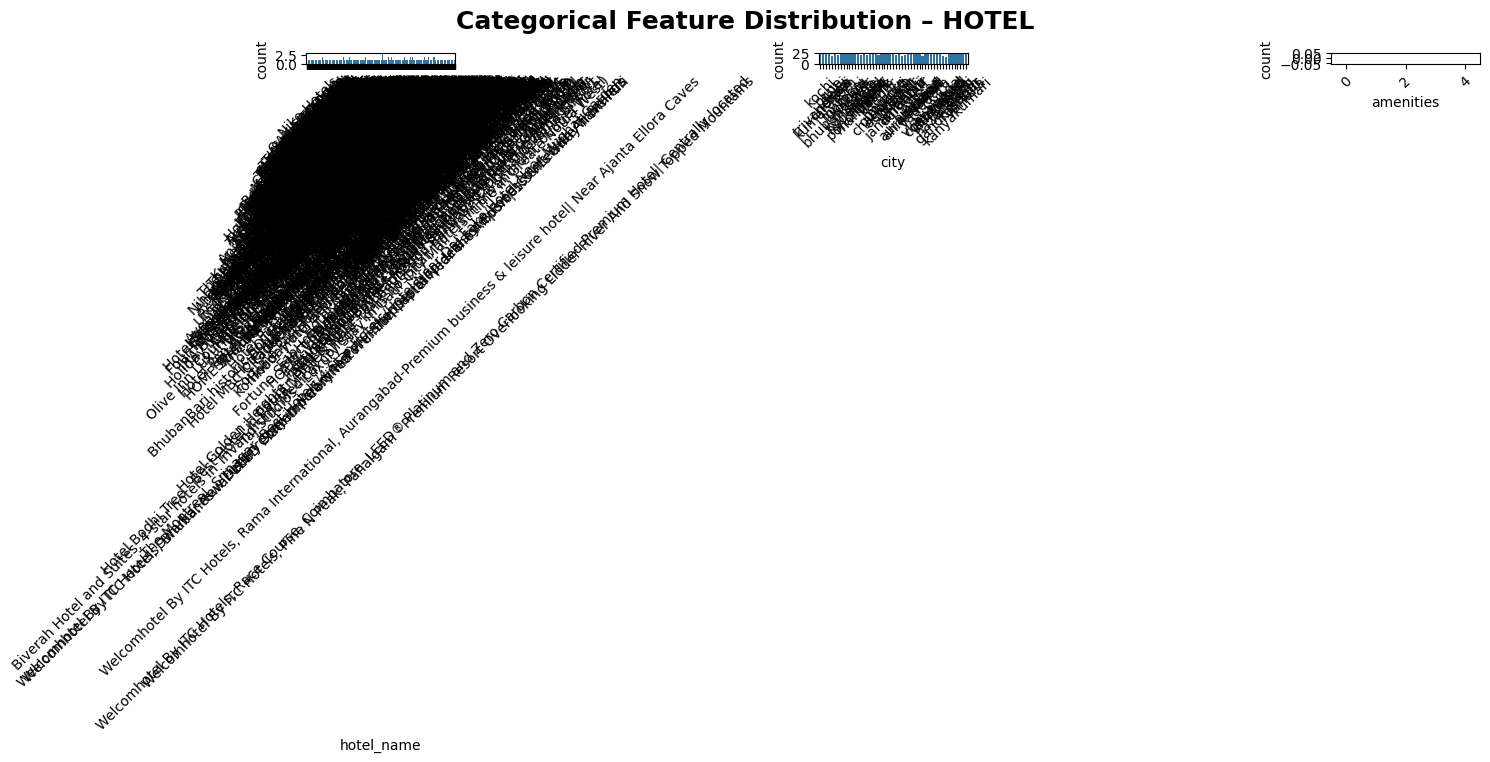

In [20]:
plt.figure(figsize=(15, 8))
plt.suptitle('Categorical Feature Distribution – HOTEL',
             fontsize=18, fontweight='bold')

for i, col in enumerate(hotel_categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=hotels_df[col])
    plt.xticks(rotation=45)
    plt.tight_layout()


CAB

2026-01-16 23:22:45,870 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-16 23:22:45,893 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-16 23:22:46,044 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-16 23:22:46,068 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


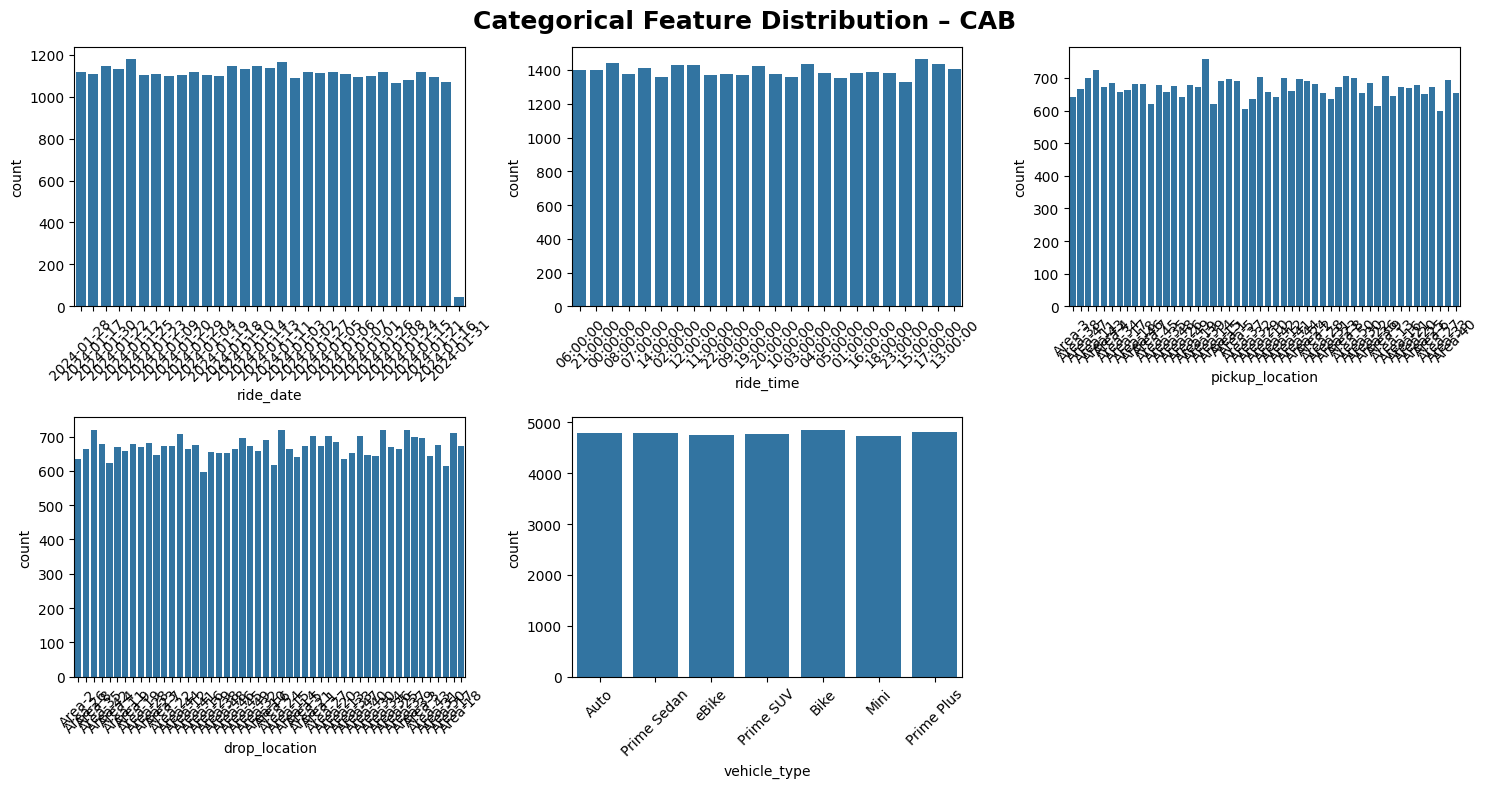

In [22]:
plt.figure(figsize=(15, 8))
plt.suptitle('Categorical Feature Distribution – CAB',
             fontsize=18, fontweight='bold')

for i, col in enumerate(cab_categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=cabs_df[col])
    plt.xticks(rotation=45)
    plt.tight_layout()


In [24]:
print("Flights Missing Values\n", flights_df.isnull().sum())
print("\nHotels Missing Values\n", hotels_df.isnull().sum())
print("\nCabs Missing Values\n", cabs_df.isnull().sum())


Flights Missing Values
 origin              0
destination         0
airline             0
dep_time            0
arr_time            0
duration_minutes    0
price               0
travel_date         0
cabin_class         0
dtype: int64

Hotels Missing Values
 hotel_name            0
city                  0
rating                0
price_per_night       0
amenities          1101
star_category         0
dtype: int64

Cabs Missing Values
 ride_date          0
ride_time          0
pickup_location    0
drop_location      0
vehicle_type       0
distance_km        0
price              0
driver_rating      0
customer_rating    0
dtype: int64


**Insights**
 - `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` coulmns have signle category dominating.
 - In rest of the columns are balanced.

### Multivariate Analysis

1. Discrete vs Continuous (Same Logic, Different Data)

In [23]:
flight_discrete_features = [
    col for col in flight_numeric_features
    if flights_df[col].nunique() <= 25
]

flight_continuous_features = [
    col for col in flight_numeric_features
    if flights_df[col].nunique() > 25
]

print("Flight Discrete Features:", flight_discrete_features)
print("Flight Continuous Features:", flight_continuous_features)


Flight Discrete Features: ['duration_minutes']
Flight Continuous Features: ['dep_time', 'arr_time', 'price']


In [25]:
hotel_discrete_features = [
    col for col in hotel_numeric_features
    if hotels_df[col].nunique() <= 25
]

hotel_continuous_features = [
    col for col in hotel_numeric_features
    if hotels_df[col].nunique() > 25
]

print("Hotel Discrete Features:", hotel_discrete_features)
print("Hotel Continuous Features:", hotel_continuous_features)


Hotel Discrete Features: ['rating', 'star_category']
Hotel Continuous Features: ['price_per_night']


In [26]:
cab_discrete_features = [
    col for col in cab_numeric_features
    if cabs_df[col].nunique() <= 25
]

cab_continuous_features = [
    col for col in cab_numeric_features
    if cabs_df[col].nunique() > 25
]

print("Cab Discrete Features:", cab_discrete_features)
print("Cab Continuous Features:", cab_continuous_features)


Cab Discrete Features: ['driver_rating', 'customer_rating']
Cab Continuous Features: ['distance_km', 'price']


* Multivariate Analysis (Correlation Heatmaps)

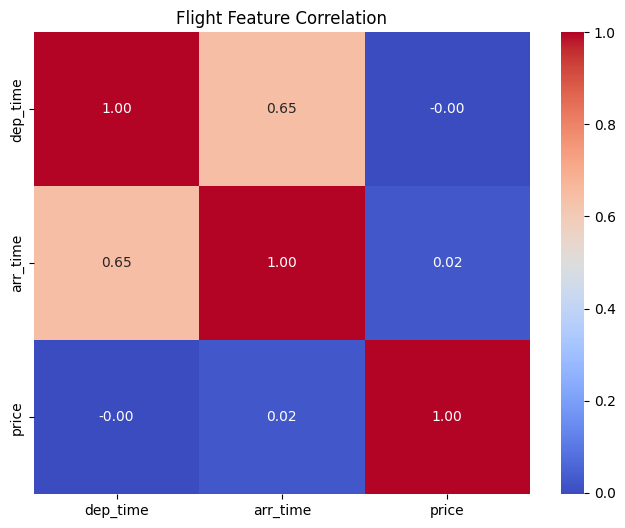

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    flights_df[flight_continuous_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Flight Feature Correlation")
plt.show()


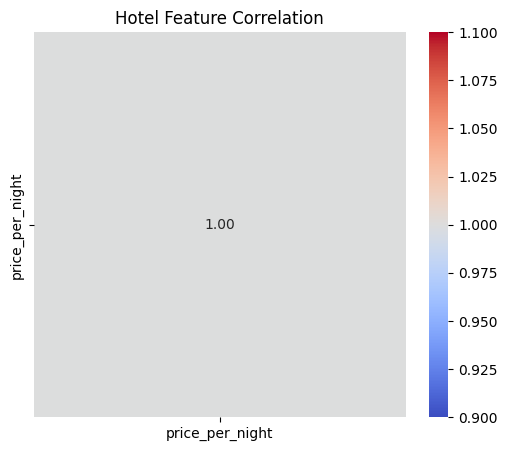

In [28]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    hotels_df[hotel_continuous_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Hotel Feature Correlation")
plt.show()


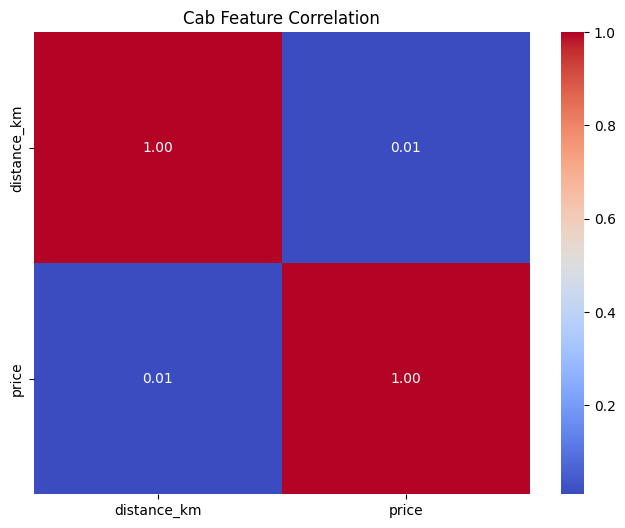

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cabs_df[cab_continuous_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Cab Feature Correlation")
plt.show()


🔹 3. Multivariate Price Relationships (RECOMMENDER-RELEVANT)

Example: Flights — Price vs Duration by Airline

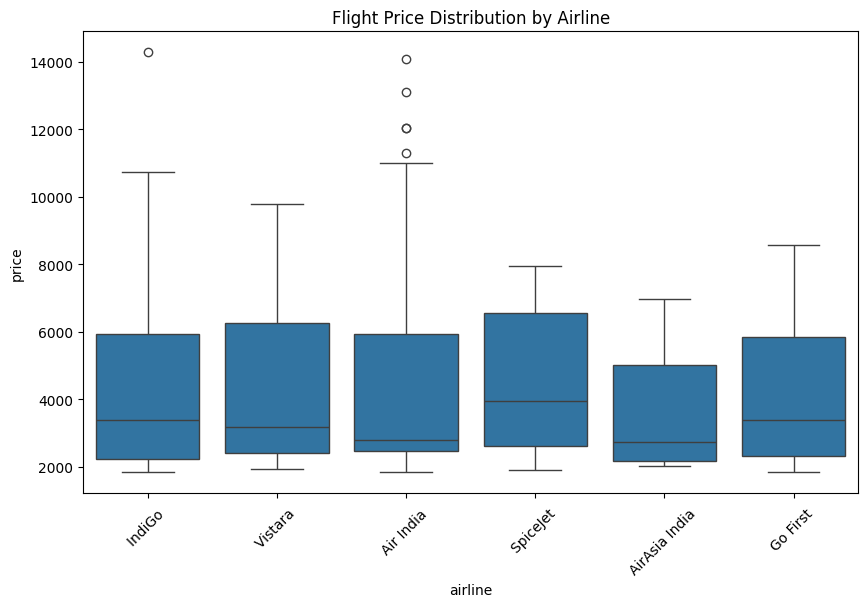

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=flights_df,
    x="airline",
    y="price"
)
plt.xticks(rotation=45)
plt.title("Flight Price Distribution by Airline")
plt.show()


Example: Hotels — Price vs Star Category

2026-01-16 23:29:46,245 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-16 23:29:46,256 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


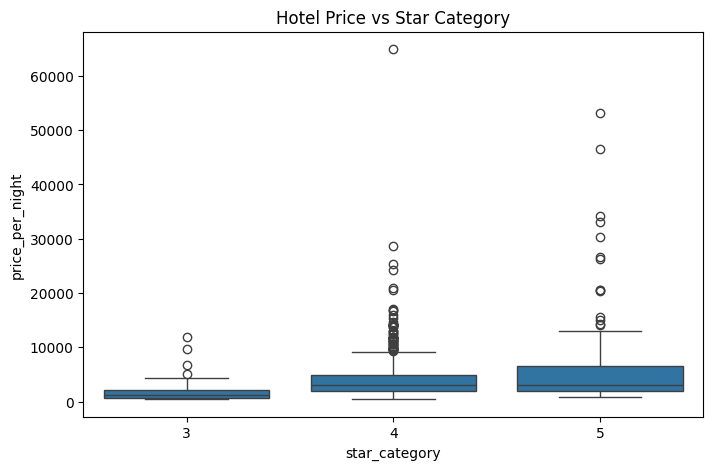

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=hotels_df,
    x="star_category",
    y="price_per_night"
)
plt.title("Hotel Price vs Star Category")
plt.show()


Example: Cabs — Price vs Vehicle Type

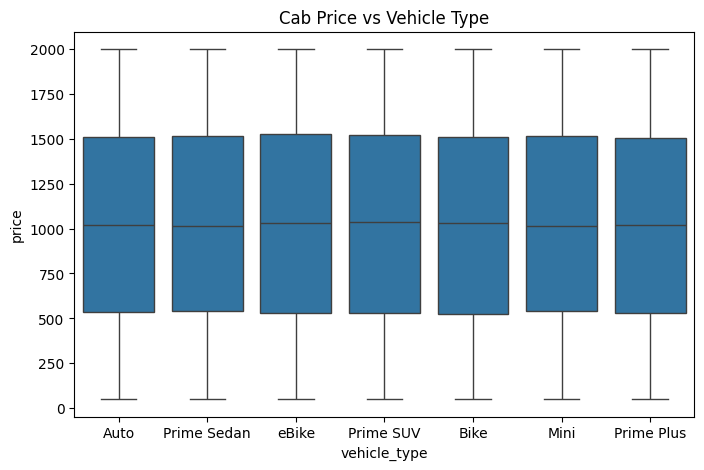

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cabs_df,
    x="vehicle_type",
    y="price"
)
plt.title("Cab Price vs Vehicle Type")
plt.show()


🔹 1. Multicollinearity in Numerical Features

(Same intent, correct method)

✈️ Flights

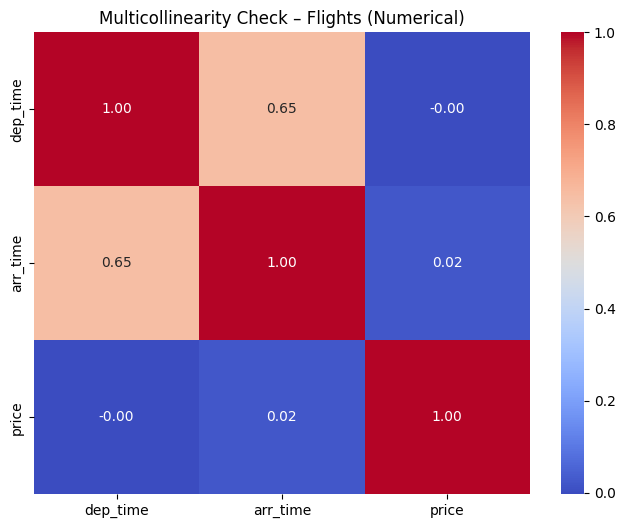

In [33]:
flights_df.head()
plt.figure(figsize=(8, 6))
sns.heatmap(
    flights_df[flight_continuous_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Multicollinearity Check – Flights (Numerical)")
plt.show()

🏨 Hotels

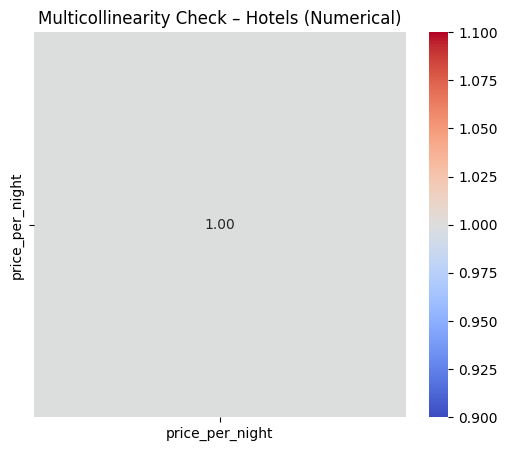

In [34]:
hotels_df.head()

plt.figure(figsize=(6, 5))
sns.heatmap(
    hotels_df[hotel_continuous_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Multicollinearity Check – Hotels (Numerical)")
plt.show()

🚕 Cabs

In [ ]:
cabs_df.head()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cabs_df[cab_continuous_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Multicollinearity Check – Cabs (Numerical)")
plt.show()

✅ Insight (write this)
No strong multicollinearity observed among numerical features.
Numeric features can be safely normalized and used together
in recommendation scoring.

* **A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test**

* **A chi-square statistic is one way to show a relationship between two categorical variables.**

* **Here we test correlation of Categorical columns with Target column i.e target_metric**

🔹 2. Categorical Dependency (REPLACES Chi-Square vs Target)

Instead of feature vs target, we check:

categorical ↔ categorical dependency

We use Cramér’s V (industry-accepted).

✅ Utility Function (ONE TIME CELL)

In [44]:
from scipy.stats import chi2_contingency
import numpy as np

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def cramers_v(x, y):
    """
    Computes Cramér's V statistic for categorical-categorical association.
    Returns np.nan if computation is not possible.
    """
    # Drop missing values pairwise
    valid = pd.concat([x, y], axis=1).dropna()

    if valid.empty:
        return np.nan

    confusion_matrix = pd.crosstab(valid.iloc[:, 0], valid.iloc[:, 1])

    # Guard: empty or degenerate matrix
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))



✈️ Flights – Categorical Dependency

In [45]:
flight_cat_dependency = []

for i in range(len(flight_categorical_features)):
    for j in range(i + 1, len(flight_categorical_features)):
        v = cramers_v(
            flights_df[flight_categorical_features[i]],
            flights_df[flight_categorical_features[j]]
        )
        flight_cat_dependency.append([
            flight_categorical_features[i],
            flight_categorical_features[j],
            v
        ])

flight_cat_df = pd.DataFrame(
    flight_cat_dependency,
    columns=["Feature_1", "Feature_2", "Cramers_V"]
)

flight_cat_df.sort_values("Cramers_V", ascending=False)

,Feature_1,Feature_2,Cramers_V
0,origin,destination,0.447214
1,origin,airline,0.136831
4,destination,airline,0.127753
7,airline,travel_date,0.072842
2,origin,travel_date,0.057753
5,destination,travel_date,0.055531
3,origin,cabin_class,NaN
6,destination,cabin_class,NaN
8,airline,cabin_class,NaN
9,travel_date,cabin_class,NaN


🏨 Hotels

In [46]:
for col in hotel_categorical_features:
    print(col, "→ unique values:", hotels_df[col].nunique())


hotel_name → unique values: 999
city → unique values: 51
amenities → unique values: 0


In [50]:
hotels_df_model = hotels_df.drop(columns=["hotel_name", "amenities"])


In [52]:
hotel_categorical_features = [
    col for col in hotels_df_model.columns
    if hotels_df_model[col].dtype == 'object'
]


In [53]:
hotel_categorical_features = [
    col for col in hotel_categorical_features
    if hotels_df_model[col].nunique() > 1
]


In [54]:
hotel_cat_dependency = []

for i in range(len(hotel_categorical_features)):
    for j in range(i + 1, len(hotel_categorical_features)):
        v = cramers_v(
            hotels_df_model[hotel_categorical_features[i]],
            hotels_df_model[hotel_categorical_features[j]]
        )

        if not np.isnan(v):
            hotel_cat_dependency.append([
                hotel_categorical_features[i],
                hotel_categorical_features[j],
                v
            ])

pd.DataFrame(
    hotel_cat_dependency,
    columns=["Feature_1", "Feature_2", "Cramers_V"]
).sort_values("Cramers_V", ascending=False)


,Feature_1,Feature_2,Cramers_V


🚕 Cabs

In [55]:
cab_cat_dependency = []

for i in range(len(cab_categorical_features)):
    for j in range(i + 1, len(cab_categorical_features)):
        v = cramers_v(
            cabs_df[cab_categorical_features[i]],
            cabs_df[cab_categorical_features[j]]
        )
        cab_cat_dependency.append([
            cab_categorical_features[i],
            cab_categorical_features[j],
            v
        ])

pd.DataFrame(
    cab_cat_dependency,
    columns=["Feature_1", "Feature_2", "Cramers_V"]
).sort_values("Cramers_V", ascending=False)

,Feature_1,Feature_2,Cramers_V
0,ride_date,ride_time,0.047437
9,drop_location,vehicle_type,0.039928
7,pickup_location,drop_location,0.038505
2,ride_date,drop_location,0.037701
1,ride_date,pickup_location,0.037595
5,ride_time,drop_location,0.037588
4,ride_time,pickup_location,0.037241
8,pickup_location,vehicle_type,0.035182
3,ride_date,vehicle_type,0.027540
6,ride_time,vehicle_type,0.025825



🔹 3. Checking Null Values (UNCHANGED, BUT PER DATASET)

In [56]:
print("Flights Nulls\n", flights_df.isnull().sum())
print("\nHotels Nulls\n", hotels_df.isnull().sum())
print("\nCabs Nulls\n", cabs_df.isnull().sum())

Flights Nulls
 origin              0
destination         0
airline             0
dep_time            0
arr_time            0
duration_minutes    0
price               0
travel_date         0
cabin_class         0
dtype: int64

Hotels Nulls
 hotel_name            0
city                  0
rating                0
price_per_night       0
amenities          1101
star_category         0
dtype: int64

Cabs Nulls
 ride_date          0
ride_time          0
pickup_location    0
drop_location      0
vehicle_type       0
distance_km        0
price              0
driver_rating      0
customer_rating    0
dtype: int64


🔹 4. Multivariate Distribution (REPLACES target-based plots)


✈️ Flights – Price vs Airline


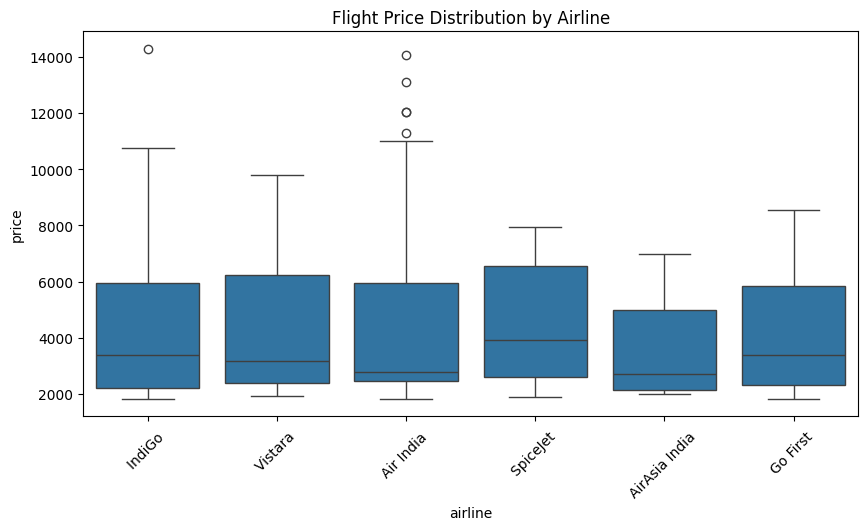

🏨 Hotels – Price vs Star Category
2026-01-16 23:40:41,279 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-16 23:40:41,288 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


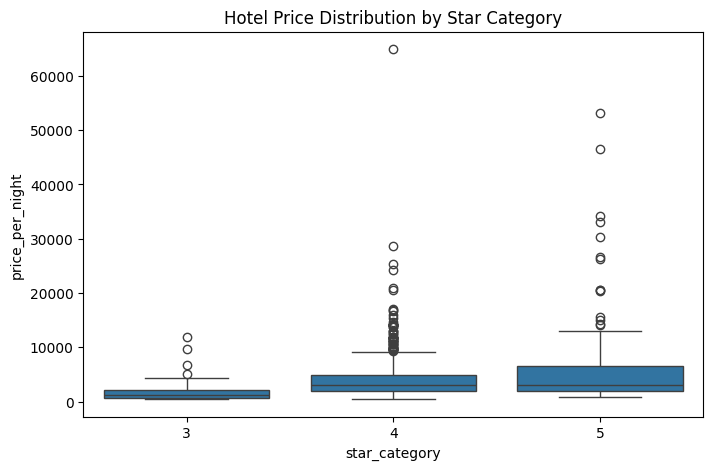

🚕 Cabs – Price vs Vehicle Type


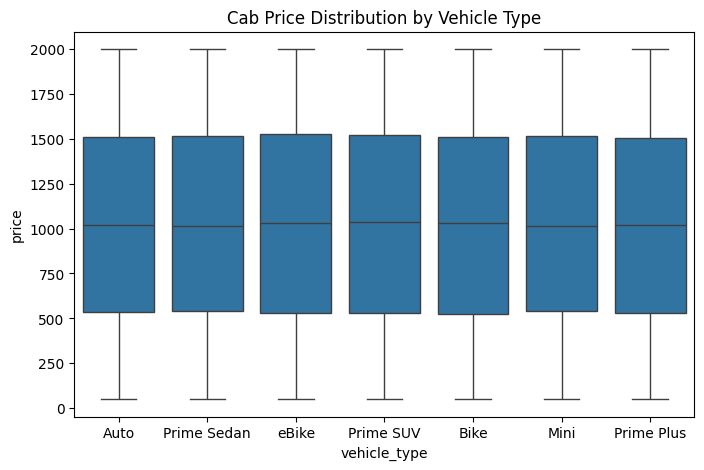

In [42]:
print("✈️ Flights – Price vs Airline")
plt.figure(figsize=(10, 5))
sns.boxplot(data=flights_df, x="airline", y="price")
plt.xticks(rotation=45)
plt.title("Flight Price Distribution by Airline")
plt.show()

print("🏨 Hotels – Price vs Star Category")
plt.figure(figsize=(8, 5))
sns.boxplot(data=hotels_df, x="star_category", y="price_per_night")
plt.title("Hotel Price Distribution by Star Category")
plt.show()

print("🚕 Cabs – Price vs Vehicle Type")
plt.figure(figsize=(8, 5))
sns.boxplot(data=cabs_df, x="vehicle_type", y="price")
plt.title("Cab Price Distribution by Vehicle Type")
plt.show()

In [57]:
print("OUTPUT 1 — FINAL COLUMNS (MOST IMPORTANT)")

# Run this for each dataset separately:

# Flights
print("Flights columns:")
print(flights_df.columns.tolist())
print("\nDtypes:")
print(flights_df.dtypes)

# Hotels
print("Hotels columns:")
print(hotels_df.columns.tolist())
print("\nDtypes:")
print(hotels_df.dtypes)

# Cabs
print("Cabs columns:")
print(cabs_df.columns.tolist())
print("\nDtypes:")
print(cabs_df.dtypes)


# 📌 This tells me:

# What can be encoded

# What must be dropped

# What is numeric vs categorical

# What can be used for similarity / ranking

print("🔹 OUTPUT 2 — MISSING VALUE SUMMARY")

# Run once per dataset:

print("Flights nulls:\n", flights_df.isnull().sum())
print("\nHotels nulls:\n", hotels_df.isnull().sum())
print("\nCabs nulls:\n", cabs_df.isnull().sum())


# 📌 This decides:

# Imputation

# Row dropping

# Feature exclusion

print("🔹 OUTPUT 3 — CATEGORICAL CARDINALITY (CRITICAL)")

# Run this exactly:

# Flights
for col in flights_df.select_dtypes(include="object").columns:
    print(col, "→", flights_df[col].nunique())

# Hotels
for col in hotels_df.select_dtypes(include="object").columns:
    print(col, "→", hotels_df[col].nunique())

# Cabs
for col in cabs_df.select_dtypes(include="object").columns:
    print(col, "→", cabs_df[col].nunique())


# 📌 This is how I decide:

# OneHotEncoder vs LabelEncoder

# Drop high-cardinality columns

# Embedding / similarity features

OUTPUT 1 — FINAL COLUMNS (MOST IMPORTANT)
Flights columns:
['origin', 'destination', 'airline', 'dep_time', 'arr_time', 'duration_minutes', 'price', 'travel_date', 'cabin_class']

Dtypes:
origin                      object
destination                 object
airline                     object
dep_time            datetime64[ns]
arr_time            datetime64[ns]
duration_minutes             int64
price                      float64
travel_date                 object
cabin_class                 object
dtype: object
Hotels columns:
['hotel_name', 'city', 'rating', 'price_per_night', 'amenities', 'star_category']

Dtypes:
hotel_name          object
city                object
rating             float64
price_per_night    float64
amenities           object
star_category        int64
dtype: object
Cabs columns:
['ride_date', 'ride_time', 'pickup_location', 'drop_location', 'vehicle_type', 'distance_km', 'price', 'driver_rating', 'customer_rating']

Dtypes:
ride_date           object
ride_time  

## Initial Analysis Report

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**
* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**
* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**
* **The `case_id` column can be deleted because each row has unique values.**
* **The `target_metric` column is the target to predict.**
* **In the Categorical column, features can be made Binary numerical in feature Encoding**

## 4. Visualization

### 4.1 Visualize the Target Feature

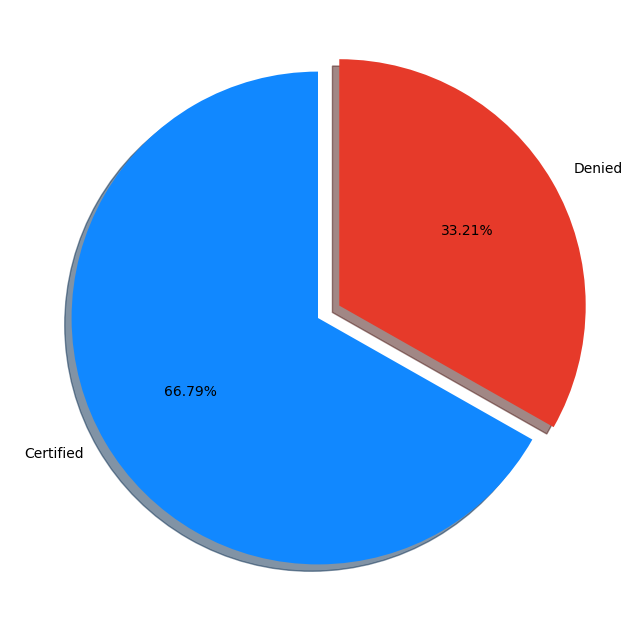

In [23]:
percentage = df.target_metric.value_counts(normalize=True)*100
labels = ["Certified","Denied"]

# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ['#1188ff','#e63a2a']
ax.pie(percentage, labels = labels, startangle = 90,
       autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()

* From the chart it is seen that the Target Variable is Imbalanced
**What is imbalanced data?**

Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

### 4.2 Does applicant Continent has any impact on travel status ?

In [24]:
#group data by continent and their count of target_metric
df.groupby('continent')['target_metric'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

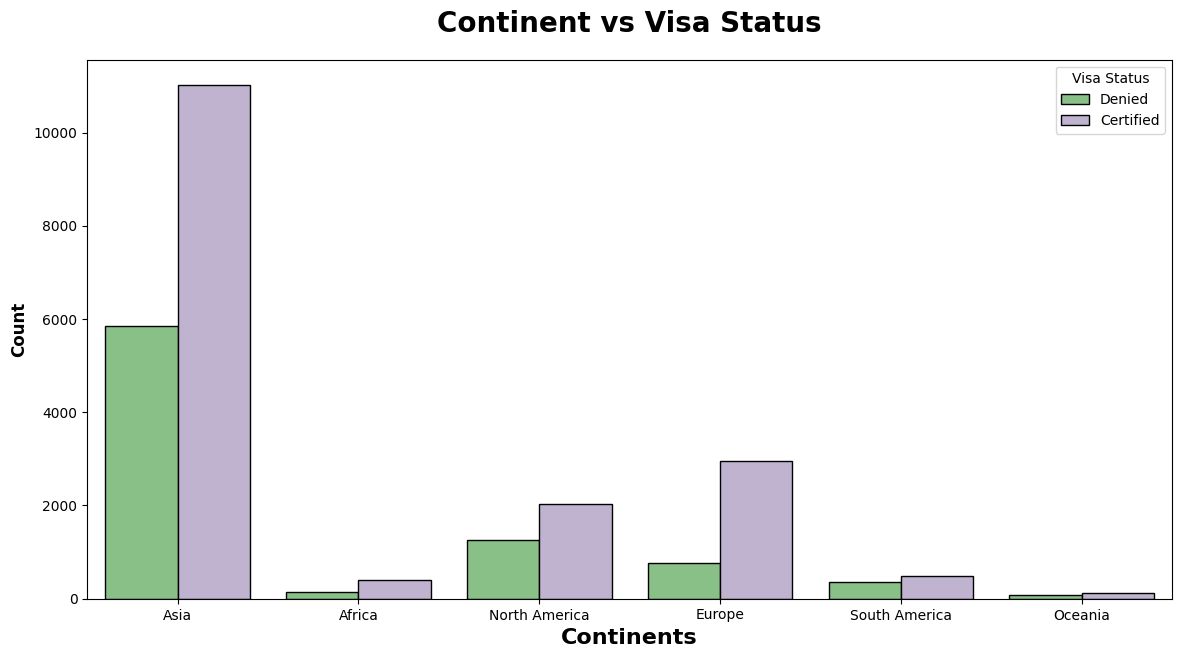

In [25]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent",hue="target_metric", data=df, ec = "black",palette="Accent")
plt.title("Continent vs travel Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continents", weight="bold", fontsize=16)
plt.legend(title="travel Status", fancybox=True)
plt.show()

In [26]:
df2 = df.copy()

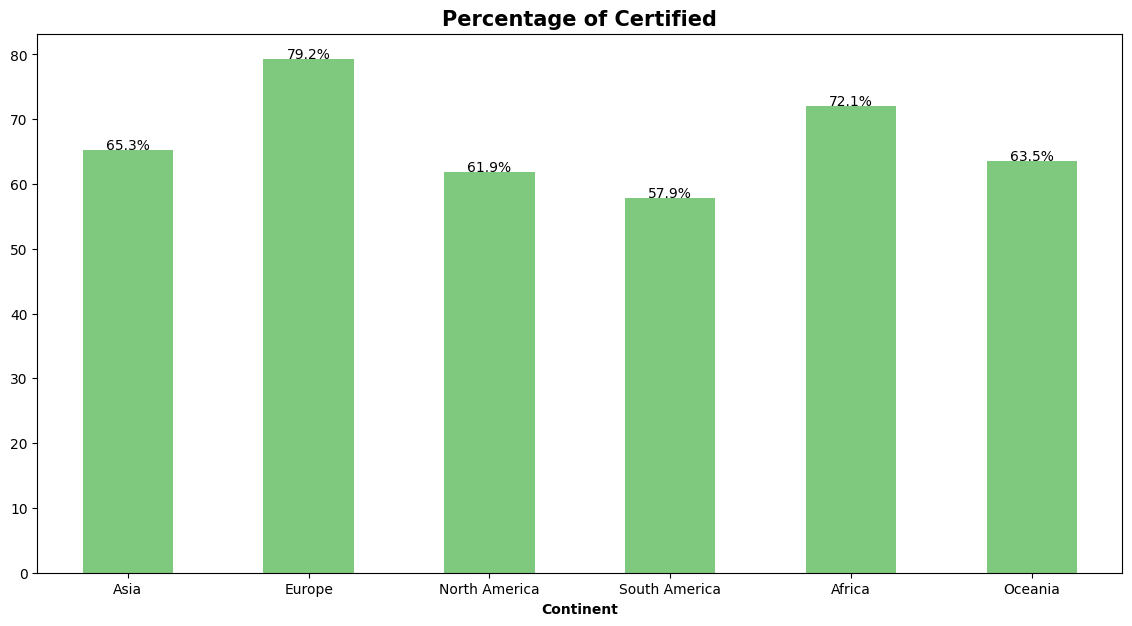

In [27]:
plt.figure(figsize=[14,7])

(100*df2[df2["target_metric"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["target_metric"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('Continent' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report:**
* As per the Chart Asia applicants applied more than other continents.
* 43% of Certified applications are from Asia.
* This is followed by Europe with 11% of Certified applications.
* Highest chance of getting certified if you are from `Europe` and followed by `Africa`

### 4.3 Does applicant rating has any impact on travel status ?

In [28]:
#group data by rating and their count of target_metric
df.groupby('education_of_employee')['target_metric'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

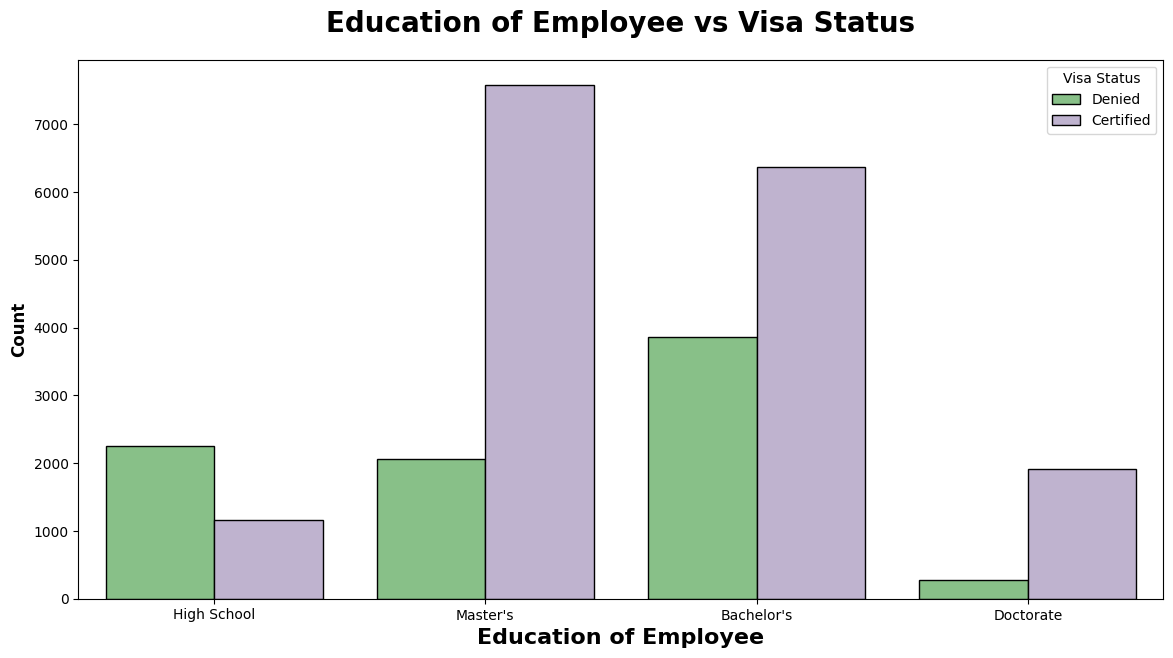

In [29]:
plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee",hue="target_metric", data=df, ec = "black",palette="Accent")
plt.title("rating of Employee vs travel Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("rating of Employee", weight="bold", fontsize=16)
plt.legend(title="travel Status", fancybox=True)
plt.show()

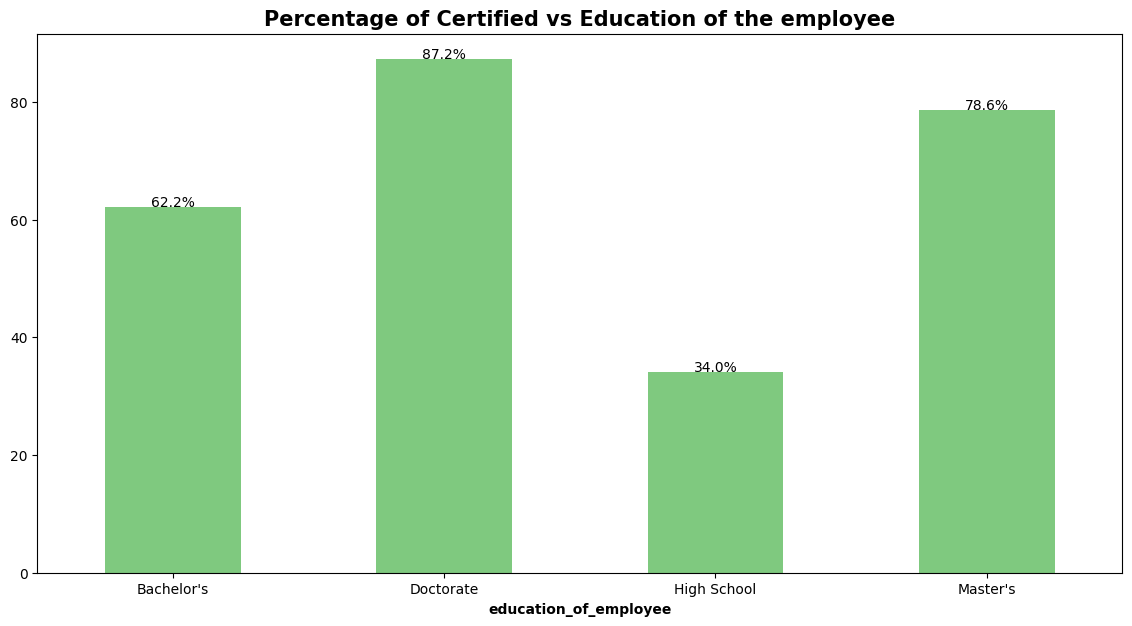

In [30]:
plt.figure(figsize=[14,7])

(100*df2[df2["target_metric"].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs rating of the employee" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["target_metric"].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('education_of_employee' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Insights**
- rating status has high impact
- `Doctorate` and `Master's` graduates have higher cange of being accepted then the others.

### 4.4 Does applicant's previous work duration has any impact on travel status ?

In [31]:
#group data by has_job_experience and count target_metric
df.groupby('has_job_experience')['target_metric'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

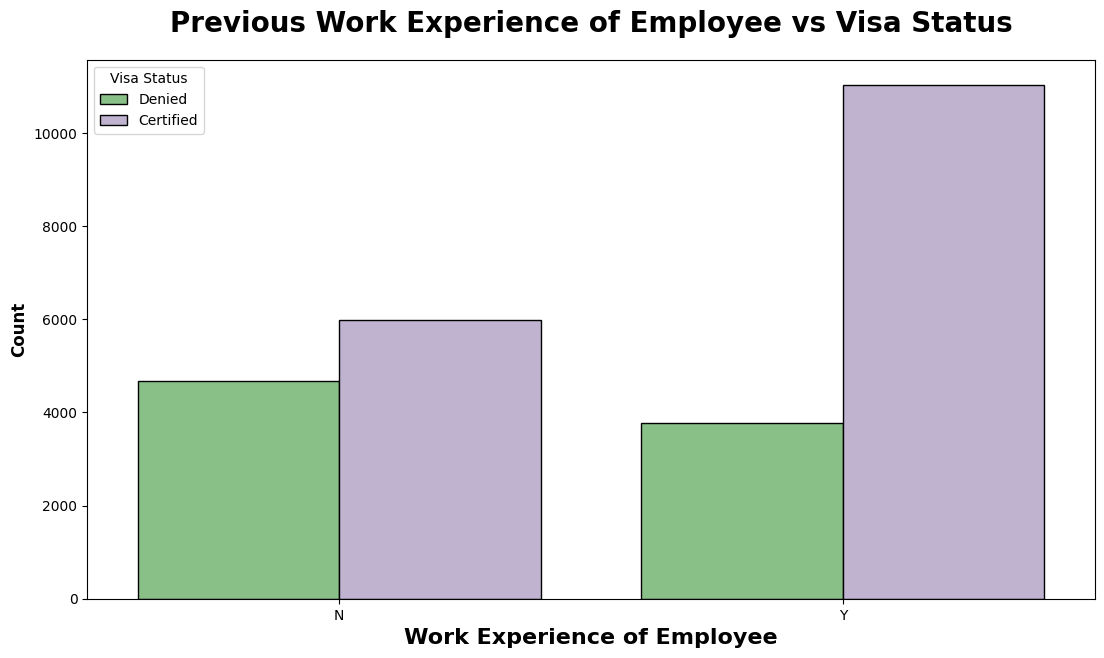

In [32]:
plt.subplots(figsize=(13,7))
sns.countplot(x="has_job_experience",hue="target_metric", data=df, ec= "black",palette="Accent")
plt.title("Previous Work duration of Employee vs travel Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Work duration of Employee", weight="bold", fontsize=16)
plt.legend(title="travel Status", fancybox=True)
plt.show()

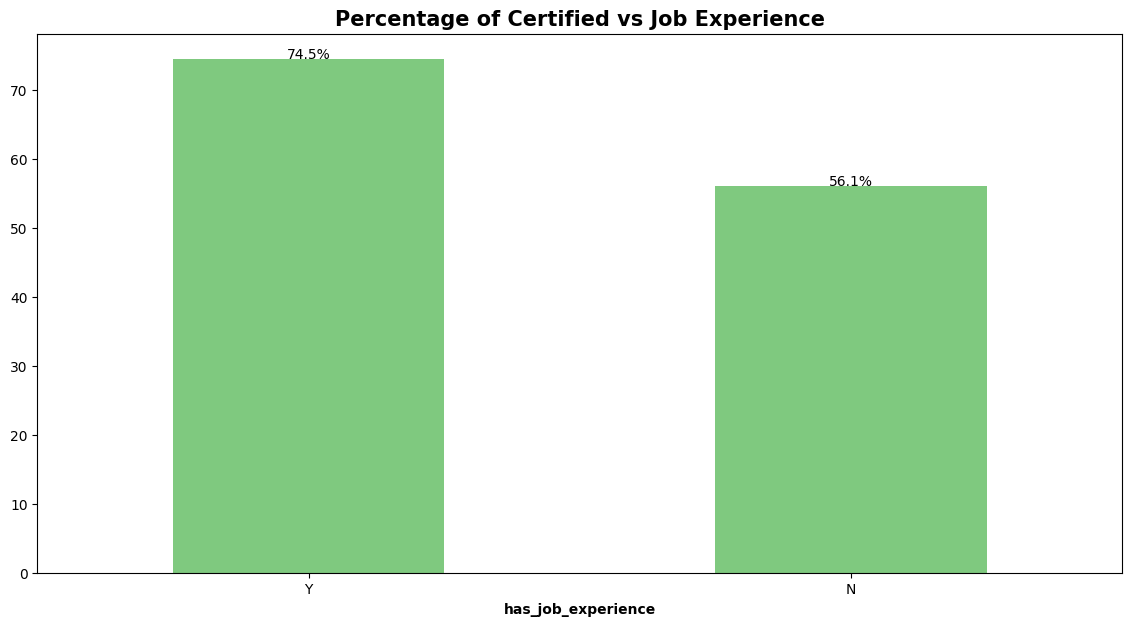

In [33]:
plt.figure(figsize=[14,7])

(100*df2[df2["target_metric"].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Job duration" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["target_metric"].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('has_job_experience' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* People with previous work duration has been certified 74.5% only 25.5% applicant has been denied.
* People with No previous work duration has been certified 56% and denied 43%.
* This means work duration has effect on travel status.
* There is a slight edge for the people with work experiences then the fresheres as expected. But the difference is not huge.

### 4.5 If the Employee requires job training, does it make any impact on travel status?

In [34]:
#group data by requires_job_training and count target_metric
df.groupby('requires_job_training')['target_metric'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

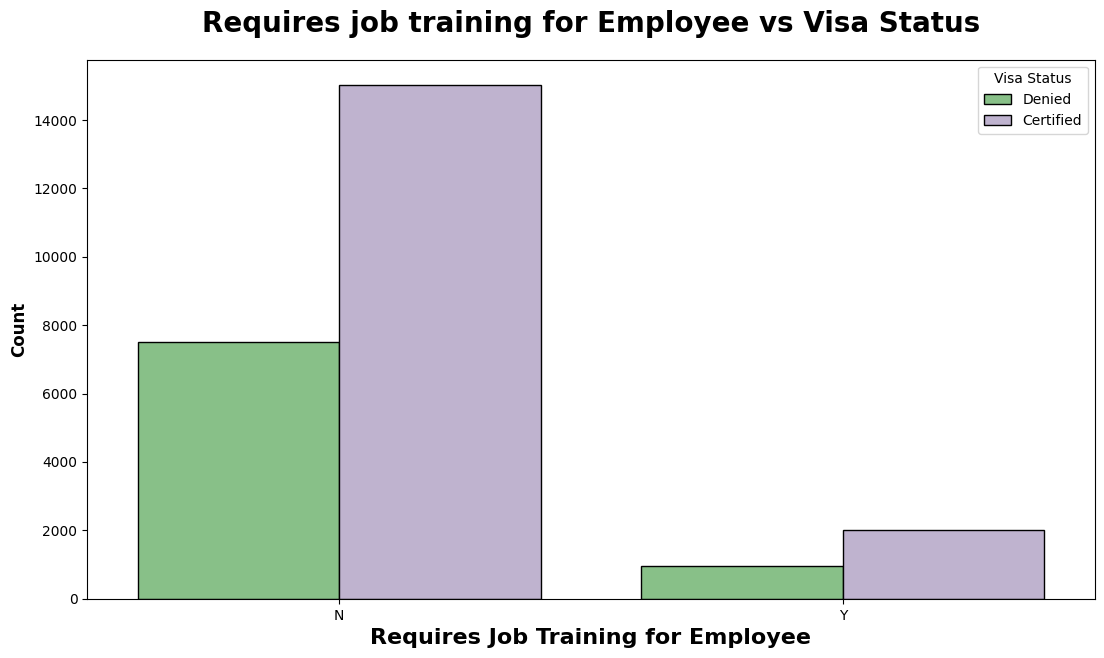

In [35]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training",hue="target_metric", data=df, ec= "black",palette="Accent")
plt.title("Requires job training for Employee vs travel Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="travel Status", fancybox=True)
plt.show()

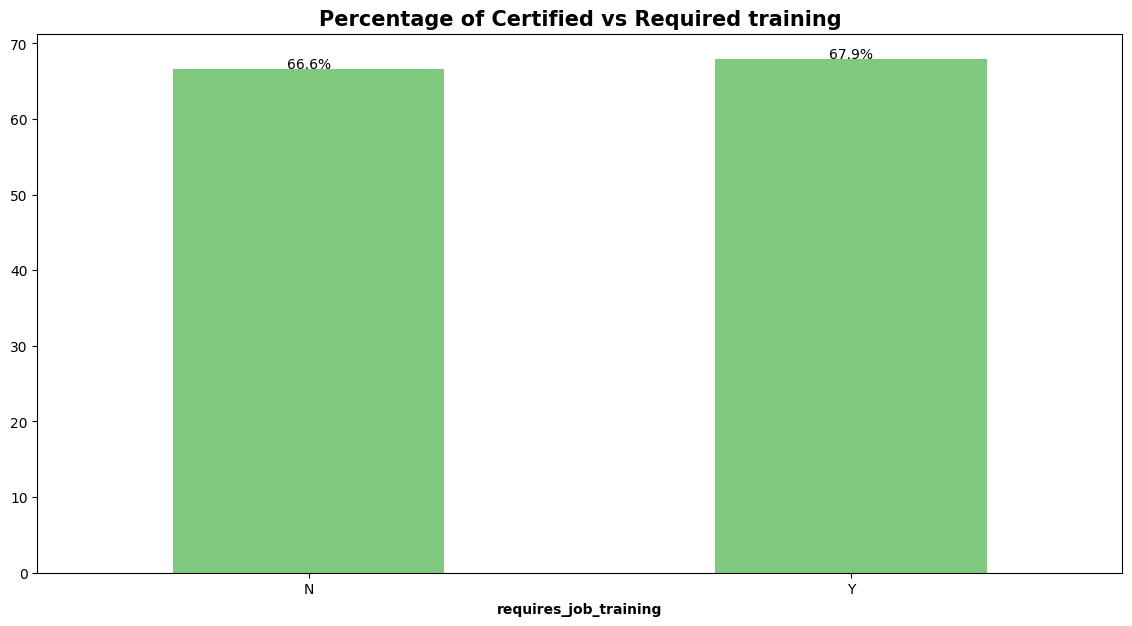

In [36]:
plt.figure(figsize=[14,7])

(100*df2[df2["target_metric"].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Required training" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["target_metric"].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('requires_job_training' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* If employee requires job training and it doesn't have any effect on travel status.
* 88% of applicant don't require job training. 
* 63% of people who doesnt want job training got certified.
* For employees who require job training 67% of people get certified.
* As we checked in Chi-Squared test this feature doesn't have much impact on target variable, which is confirmed by above plot.

### 4.6 Does Number of employees of service_provider has any impact on travel status?

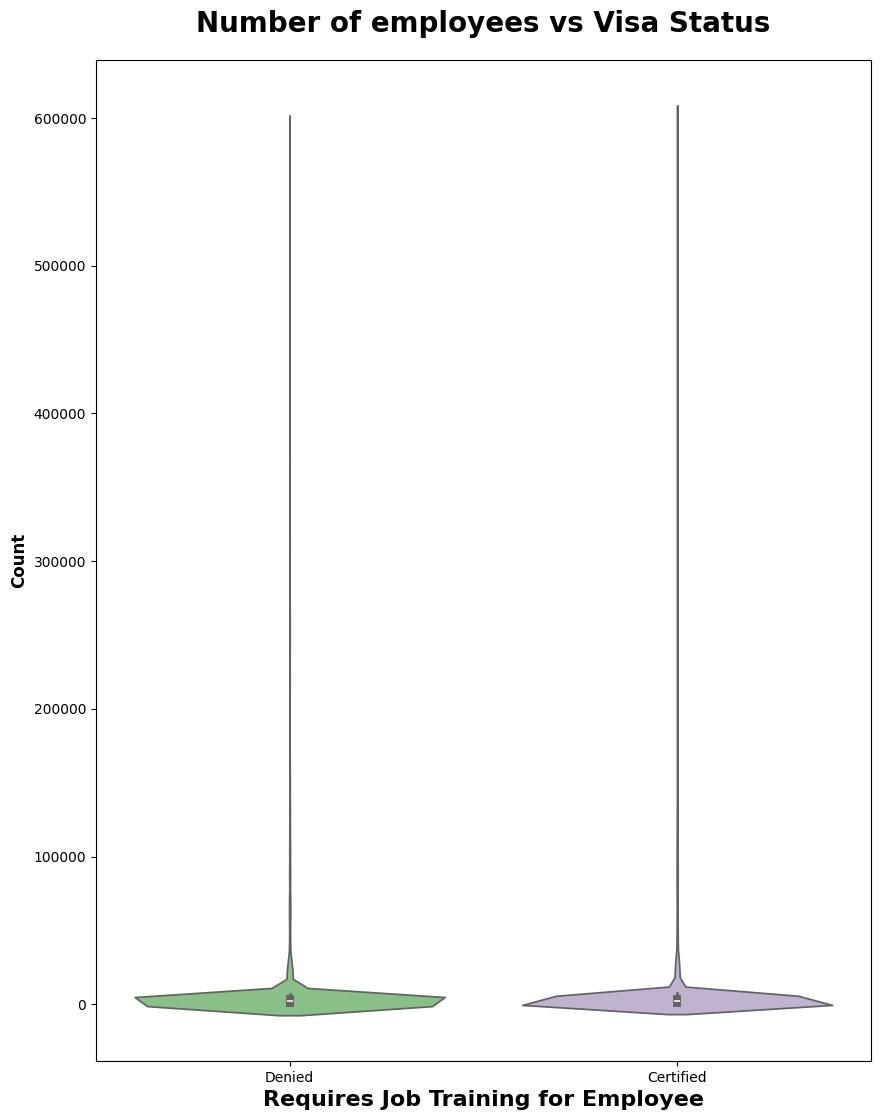

In [37]:
plt.subplots(figsize=(10,13))
sns.violinplot(x="target_metric",y='no_of_employees', data=df, palette="Accent")
plt.title("Number of employees vs travel Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()

**Insights**
 - The distrubution of both is similar. But there are outliers in both the classes which need to be handeled.

### 4.7 Wages and its impact on travel status

In [38]:
#group data by unit_of_wage and count the target_metric
df.groupby('unit_of_wage')['target_metric'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

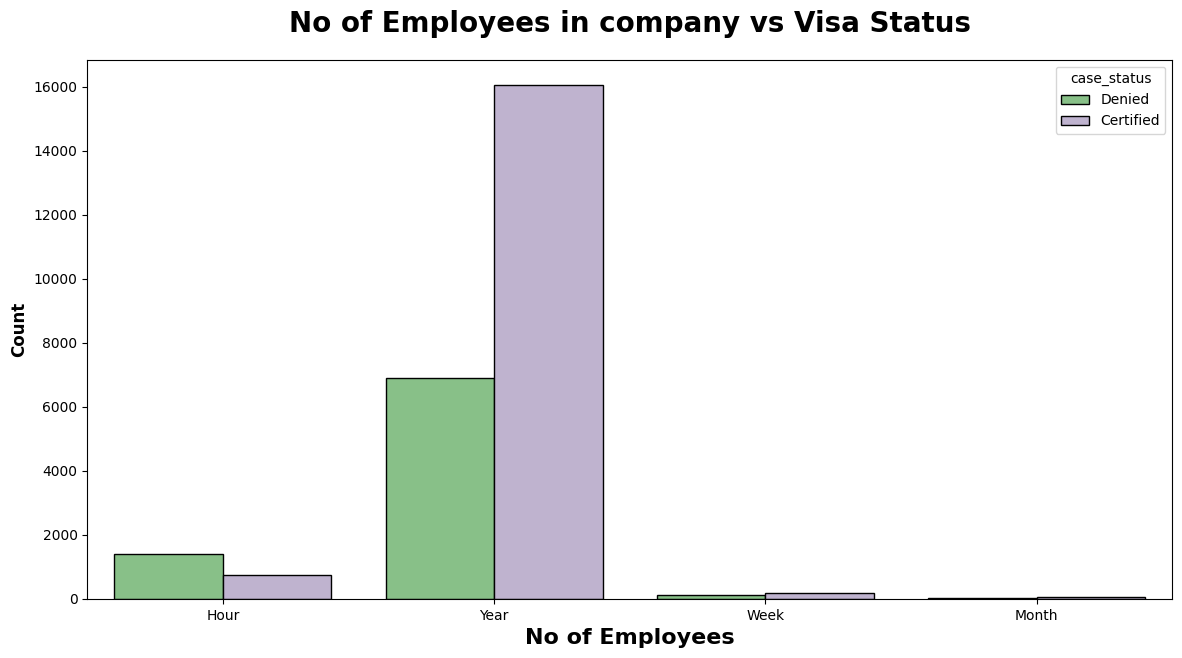

In [39]:
plt.subplots(figsize=(14,7))
sns.countplot(x="unit_of_wage",hue="target_metric", data=df,ec='k', palette='Accent')
plt.title("No of Employees in company vs travel Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("No of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

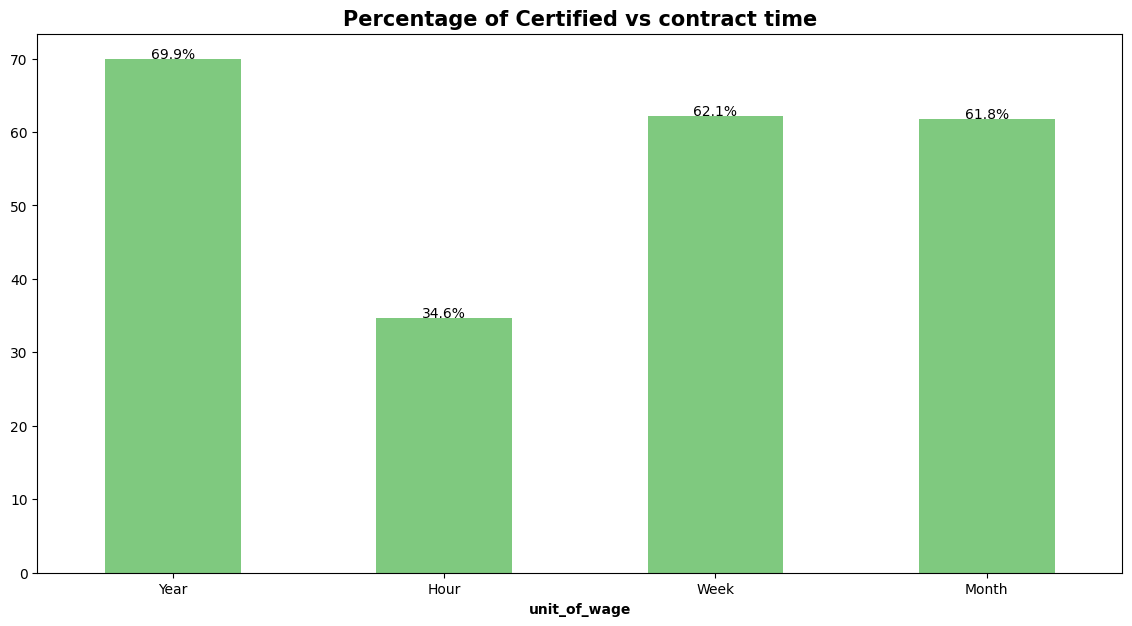

In [40]:
plt.figure(figsize=[14,7])

(100*df2[df2["target_metric"].isin(['Certified'])]['unit_of_wage'].value_counts()/df2['unit_of_wage'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs contract time" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["target_metric"].isin(['Certified'])]['unit_of_wage'].value_counts()/df2['unit_of_wage'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('unit_of_wage' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* For employees who applied for hourly pay 65% of them were denied.
* Yearly unit price application were accepted for 69% and denied for 31% of the time.
* There is a higher chance of yearly contract than other and immediately followed by week and month.

### 4.7 Does Region of employment has impact on travel status ?

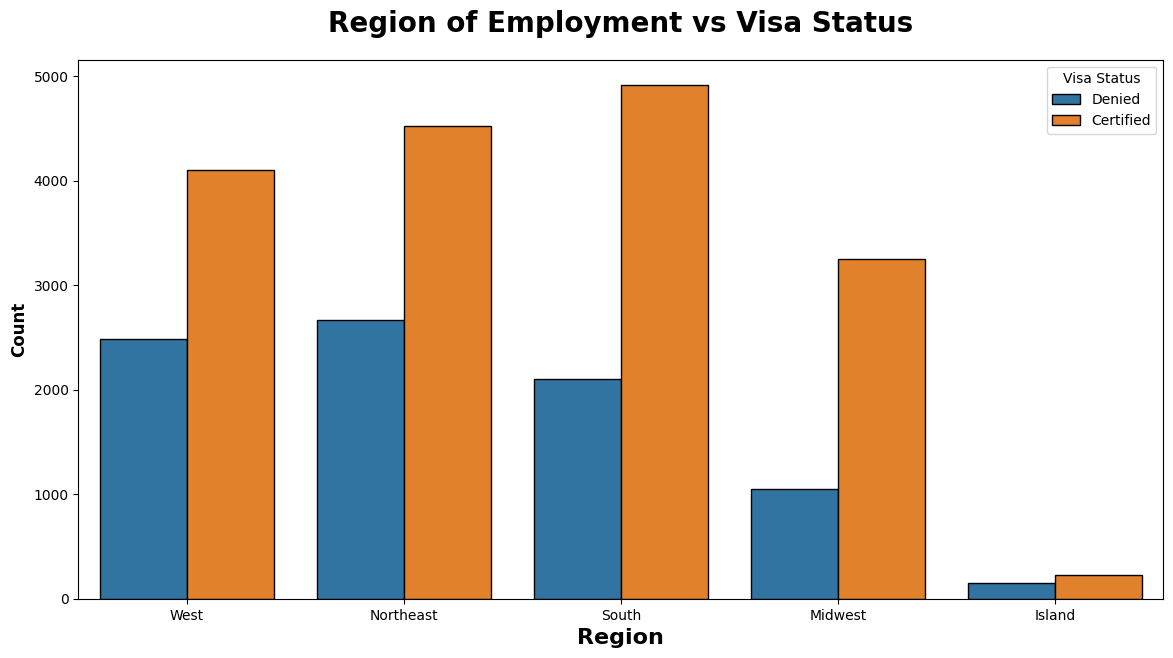

In [41]:
plt.subplots(figsize=(14,7))
sns.countplot(x="region_of_employment",hue="target_metric", data=df,ec='k')
plt.title("Region of Employment vs travel Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="travel Status", fancybox=True)
plt.show()

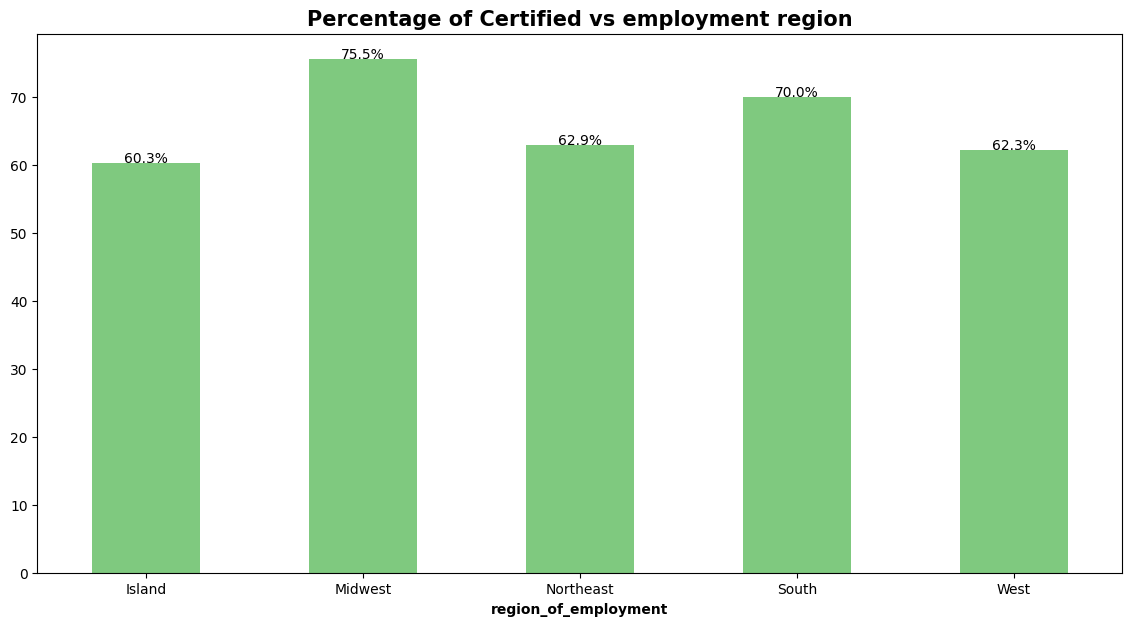

In [42]:
plt.figure(figsize=[14,7])

(100*df2[df2["target_metric"].isin(['Certified'])]['region_of_employment'].value_counts()/df2['region_of_employment'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs employment region" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["target_metric"].isin(['Certified'])]['region_of_employment'].value_counts()/df2['region_of_employment'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('region_of_employment' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report** 
* As per chart all the region have very similar pattern of getting travel certified and Denied.
* There is a slight edge for `midwest` followed by `South` region

### 4.8 Does Prevailing price has any impact on travel status ?

In [43]:
df.groupby('prevailing_wage').target_metric.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

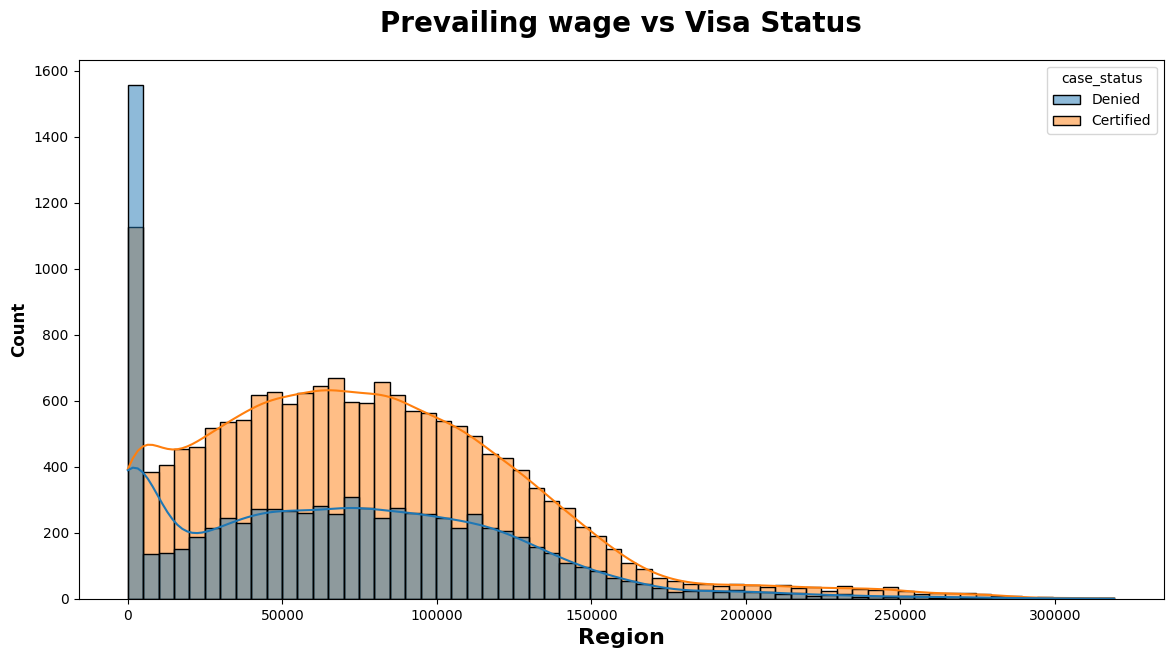

In [44]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage",hue="target_metric", data=df, kde=True)
plt.title("Prevailing price vs travel Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

**Insights**
 - The distribution of both the classes are same but need to handel the outliers.

#### 4.8.1 Prevailing price based on rating

In [45]:
print('Average Prevailing price based on Employee rating')
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Employee education


,prevailing_wage
education_of_employee,
Master's,78843.057843
Bachelor's,73405.443735
High School,71582.147756
Doctorate,64561.076657


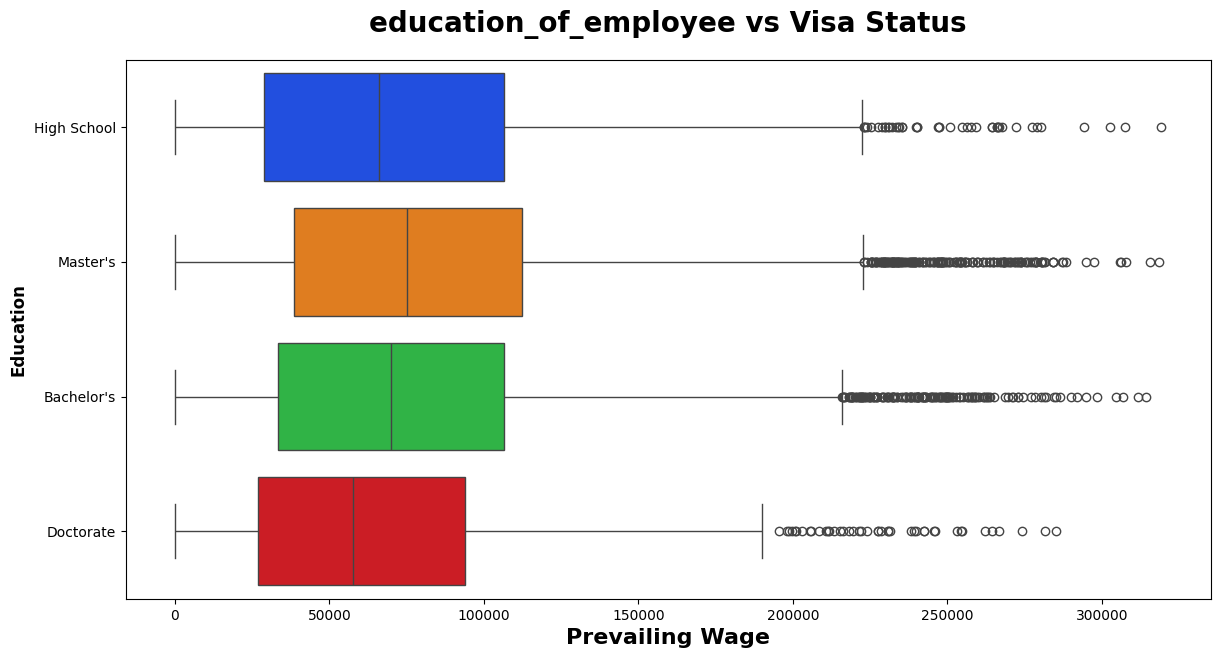

In [46]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="education_of_employee",x = "prevailing_wage", data=df,palette='bright')
plt.title("education_of_employee vs travel Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing price", weight="bold", fontsize=16)
plt.ylabel("rating", weight="bold", fontsize=12)
plt.show()

**Report**
* Based on the above table and charts its seen that applicant with Master's rating has higher average prevailing wages.
* Master's rating applicants have median price of $78.8k, which approximately 20% higher than Doctrate's average price, which is strange.

#### 4.8.2 Prevailing price based on Job duration

In [47]:
print('Median Prevailing price based on Job duration')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage',ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


**Report**
* Suprisingly people who has less job duration has more prevailing price.
* No job duration applicant has median prevailing price as 72k USD.
* Previous job duration applicant has median prevailing price as 69K USD.

#### 4.8.3 Prevailing price based on Continent

In [48]:
print('Average Prevailing price based on Continent')
df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Continent


,prevailing_wage
continent,
Asia,79543.021780
Africa,77425.923450
Oceania,75994.276719
North America,68066.319257
South America,60209.575314
Europe,59842.925899


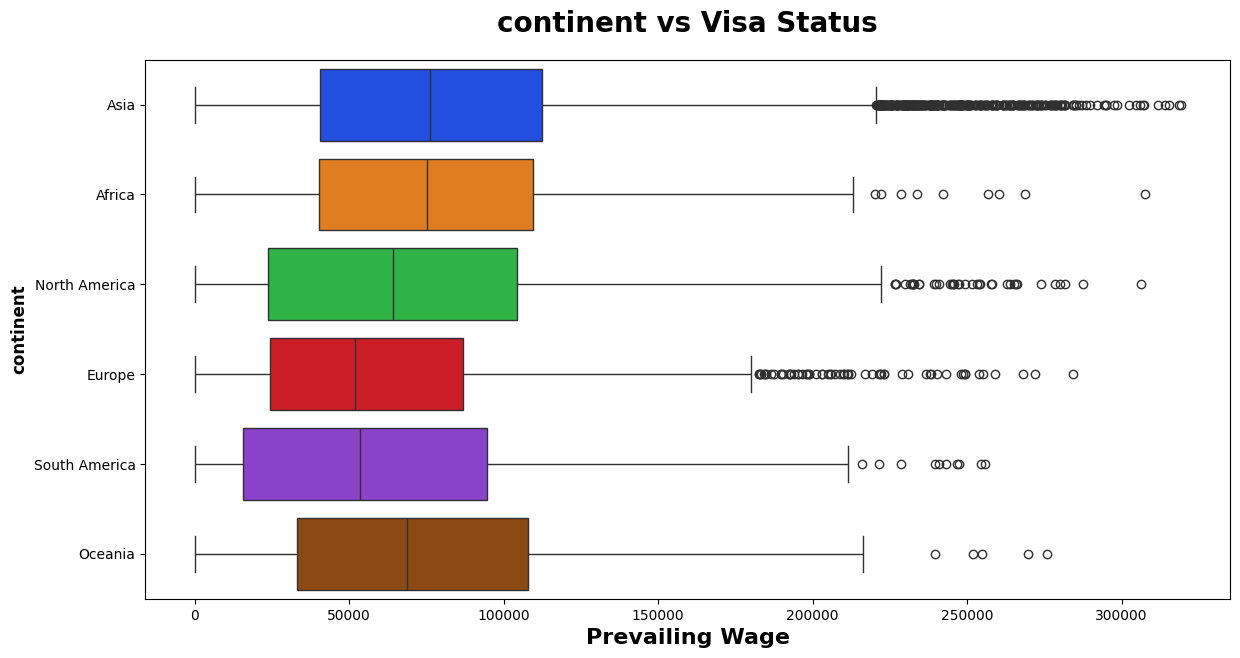

In [49]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="continent",x = "prevailing_wage", data=df,palette='bright')
plt.title("continent vs travel Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing price", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()

**Report**
* Average price of people from Asia is higher than other continents.

### 4.9 Year of Establishment 

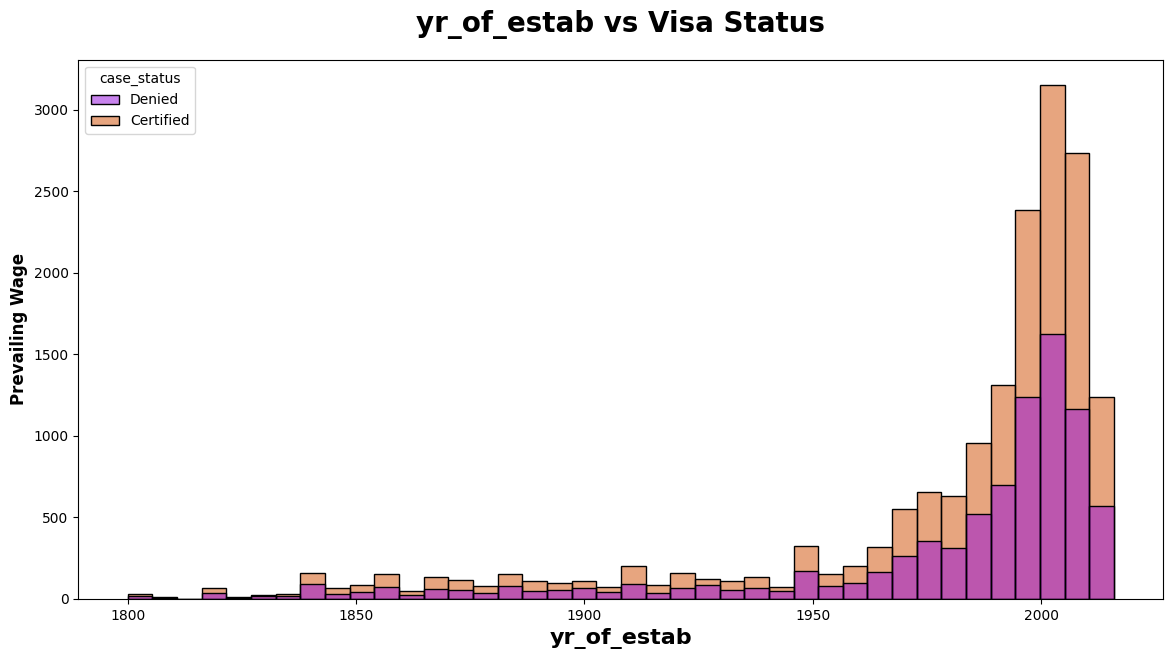

In [50]:
plt.subplots(figsize=(14,7))
sns.histplot(x = "yr_of_estab", data=df,palette='gnuplot', bins=40, hue='target_metric')
plt.title("yr_of_estab vs travel Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing price", weight="bold", fontsize=12)
plt.show()

**Report**
* Each bins consists of 5 years.
* Many companies were established after year 2000.
* The most company establishment happened in year 2000-2005.

### Final Report 
* `case_id` column can be dropped as it is an ID.
* `requires_job_training` column can be dropped as it doesn't have much impact on target variable, Proved in visualization and chi2 test.
* `no_of_employees`, `prevailing_wage` columns have outllier which should be handled.
* `continent` columns has few unique values with very less count, which can be made as **others**
* Target column `target_metric` is imbalanced can be handled before model building.

In [ ]:
########################-------------Feature Engineering and Model Training in Next ipynb------------###########################